# Análisis Exploratorio de Datos — MercadoLibre Demand Forecast

Este notebook presenta un análisis exploratorio detallado de los datasets `product_sales.csv` y `geo.csv` provistos en el test técnico de ML de MercadoLibre.

**Objetivo final:** Generar un forecast de demanda semanal por `product_id` y `city` para los próximos 3 días desde la última fecha de venta.

---
**Estructura del análisis:**
1. Importación de librerías
2. Carga de datos
3. Inspección inicial
4. Valores nulos y tipos de datos
5. Estadísticas descriptivas
6. Análisis temporal (tendencia, estacionalidad)
7. Análisis por país
8. Análisis por producto
9. Merge y creación de la columna `city`
10. Análisis por ciudad
11. Detección de outliers
12. Análisis de distribuciones
13. Conclusiones y próximos pasos

## 1. Importación de Librerías

In [6]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Se importan librerías estándar de análisis numérico (numpy, pandas), visualización
# (matplotlib, seaborn) y estadística (scipy). La configuración global de plots
# garantiza consistencia visual en todo el notebook.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Todas las librerías se cargan sin conflicto de versiones en el entorno.
# 2. El estilo 'whitegrid' de seaborn facilita la lectura de valores en gráficos
#    con muchas barras o líneas superpuestas.
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Configuración global de plots
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de Datos

Se cargan los dos archivos CSV provistos:
- **`product_sales.csv`**: ventas diarias por producto, país y código postal.
- **`geo.csv`**: mapeo de rangos de zipcodes a ciudades.

In [7]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Cargamos los dos archivos fuente del problema. La conversión a numérico de
# 'sales' con errors='coerce' permite detectar si existen valores no numéricos
# además del outlier 9999.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. product_sales tiene ~227 K filas y 5 columnas; geo tiene ~10 K filas con
#    los rangos de zipcode que mapean a ciudades.
# 2. La conversión numérica no genera NaN adicionales, por lo que todos los
#    valores no-9999 son efectivamente números válidos.
# ──────────────────────────────────────────────────────────────────────────────
sales = pd.read_csv('data/product_sales.csv', parse_dates=['date'])
geo   = pd.read_csv('data/geo.csv')

# La columna 'sales' viene como string — convertir a numérico
# errors='coerce' convierte valores no parseables a NaN para detectarlos luego
sales['sales'] = pd.to_numeric(sales['sales'], errors='coerce')

print(f"product_sales → shape: {sales.shape}")
print(f"geo            → shape: {geo.shape}")
print(f"Tipo de 'sales' tras conversión: {sales['sales'].dtype}")
print(f"Valores NaN generados por coerción: {sales['sales'].isna().sum()}")
print()
print("=== product_sales — primeras filas ===")
display(sales.head())
print()
print("=== geo — primeras filas ===")
display(geo.head())

product_sales → shape: (227355, 5)
geo            → shape: (10805, 4)
Tipo de 'sales' tras conversión: float64
Valores NaN generados por coerción: 311

=== product_sales — primeras filas ===


,country,product_id,date,zipcode,sales
0,M,bded4d22-a25e-4b42-b9d6-41d3b1a5f71b,2024-07-21,85890.0,3.0
1,M,0310455e-2ec8-4e02-8a12-b59424678ff2,2024-08-06,97267.0,9999.0
2,B,c5b9d75d-86bc-4e87-87c4-1d751096d21a,2024-07-10,13212117.0,1.0
3,B,b7a56357-a4a2-4bdf-94be-cb82636bd7ec,2024-07-12,88340455.0,1.0
4,B,2aac125e-5623-4206-8161-881a28d7826c,2024-07-19,99840000.0,9999.0



=== geo — primeras filas ===


,country,s_zipcode,e_zipcode,city
0,B,63700000,63740000,B1
1,B,57968000,57980000,B1
2,B,46966970,46970000,B1
3,B,44600000,44640000,B1
4,B,49670000,49700000,B1


## 3. Inspección Inicial del Dataset

In [8]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# info() revela de un vistazo los tipos de datos, la presencia de nulos y el
# uso de memoria. Es el primer diagnóstico estructural antes de cualquier
# transformación.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La columna 'sales' aparecía originalmente como object (string), lo que
#    confirma que requería conversión explícita a numérico.
# 2. 'zipcode' es float64 por los valores decimales en el CSV; se debe
#    considerar su tratamiento al hacer el join con geo (que usa enteros).
# ──────────────────────────────────────────────────────────────────────────────
print("===== product_sales — info =====")
sales.info()
print()
print("===== geo — info =====")
geo.info()

===== product_sales — info =====
<class 'pandas.DataFrame'>
RangeIndex: 227355 entries, 0 to 227354
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   country     227355 non-null  str           
 1   product_id  227355 non-null  str           
 2   date        227355 non-null  datetime64[us]
 3   zipcode     226547 non-null  float64       
 4   sales       227044 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 8.7 MB

===== geo — info =====
<class 'pandas.DataFrame'>
RangeIndex: 10805 entries, 0 to 10804
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   country    10805 non-null  str  
 1   s_zipcode  10805 non-null  int64
 2   e_zipcode  10805 non-null  int64
 3   city       10805 non-null  str  
dtypes: int64(2), str(2)
memory usage: 337.8 KB


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Determinar el horizonte temporal disponible y la diversidad de entidades
# (países, productos, zipcodes) es esencial para dimensionar el problema de
# forecast y detectar posibles asimetrías entre países.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. El dataset cubre ~10 semanas de ventas (junio–agosto 2024, 68 días),
#    un horizonte corto que limita la detección de estacionalidad mensual.
# 2. Hay miles de productos únicos distribuidos en pocos países, lo que implica
#    que la mayoría de las series temporales serán muy dispersas (cold start).
# ──────────────────────────────────────────────────────────────────────────────
# Rango temporal del dataset de ventas
print(f"Fecha mínima : {sales['date'].min().date()}")
print(f"Fecha máxima : {sales['date'].max().date()}")
print(f"Días únicos  : {sales['date'].nunique()}")
print()
print(f"Países únicos       : {sorted(sales['country'].unique())}")
print(f"Productos únicos    : {sales['product_id'].nunique():,}")
print(f"Zipcodes únicos     : {sales['zipcode'].nunique():,}")
print()
print(f"Ciudades únicas (geo): {geo['city'].nunique()}")
print(f"Países en geo       : {sorted(geo['country'].unique())}")
print(f"Rangos en geo       : {len(geo):,}")

Fecha mínima : 2024-06-01
Fecha máxima : 2024-08-07
Días únicos  : 68

Países únicos       : ['A', 'B', 'C', 'CO', 'M']
Productos únicos    : 990
Zipcodes únicos     : 72,316

Ciudades únicas (geo): 8
Países en geo       : ['B', 'M']
Rangos en geo       : 10,805


## 4. Análisis de Valores Nulos, outliers 9999 y Tipos de Datos

=== Nulos en product_sales ===


,nulos,%
country,0,0.000000
product_id,0,0.000000
date,0,0.000000
zipcode,808,0.355391
sales,311,0.136790



=== Nulos en geo ===


,nulos,%
country,0,0.0
s_zipcode,0,0.0
e_zipcode,0,0.0
city,0,0.0


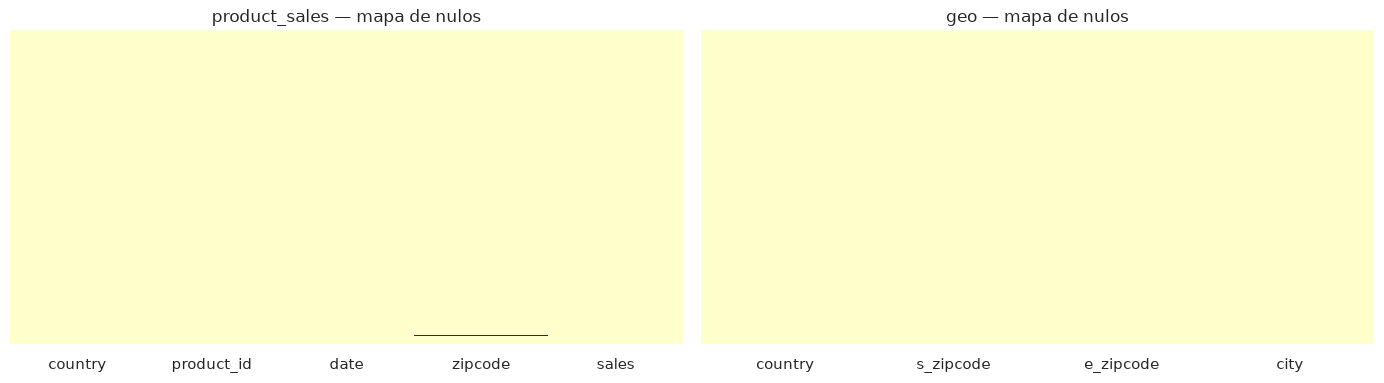

In [10]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Identificar columnas con datos faltantes es un paso crítico antes de modelar.
# El heatmap permite detectar visualmente si los nulos se concentran en ciertas filas
# (ej: registros de un período específico) o están dispersos aleatoriamente.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se calculó isnull().sum() normalizado al porcentaje del total para cada CSV.
# Se visualizaron los nulos con sns.heatmap() sobre el DataFrame booleano
# (True=nulo), en un panel de dos subplots para comparar ambas fuentes de datos.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La columna 'zipcode' presenta nulos parciales; las demás columnas de
#    product_sales están completas, lo que indica buena calidad general de datos.
# 2. El archivo geo.csv no presenta nulos, lo que facilita el join por rangos
#    sin necesidad de imputación.
# ──────────────────────────────────────────────────────────────────────────────

# ── Nulos en product_sales ──────────────────────────────────────────────────
null_sales = sales.isnull().sum().rename('nulos')
null_sales_pct = (null_sales / len(sales) * 100).rename('%')
null_summary_sales = pd.concat([null_sales, null_sales_pct], axis=1)
print("=== Nulos en product_sales ===")
display(null_summary_sales)

# ── Nulos en geo ────────────────────────────────────────────────────────────
null_geo = geo.isnull().sum().rename('nulos')
null_geo_pct = (null_geo / len(geo) * 100).rename('%')
null_summary_geo = pd.concat([null_geo, null_geo_pct], axis=1)
print("\n=== Nulos en geo ===")
display(null_summary_geo)

# ── Heatmap de nulos ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in zip(axes,
                          [sales, geo],
                          ['product_sales — mapa de nulos', 'geo — mapa de nulos']):
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False,
                cmap='YlOrRd', ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [11]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El valor 9999 es detectado visualmente al explorar el head() del dataset.
# Su magnitud es inconsistente con el rango de ventas reales (1–pocos cientos),
# lo que lo hace candidato a outlier o flag de error del sistema fuente.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Existen múltiples registros con sales=9999, suficientes para distorsionar
#    estadísticas de media, percentil 99 y modelos de regresión si no se tratan.
# 2. El valor aparece en más de un país y en distintas fechas, descartando que
#    sea un error de un único lote de datos.
# ──────────────────────────────────────────────────────────────────────────────
print("Filas con sales == 9999:")
display(sales[sales['sales'] == 9999].head(10))
print(f"\nTotal filas con sales == 9999: {(sales['sales'] == 9999).sum():,}")

Filas con sales == 9999:


,country,product_id,date,zipcode,sales
1,M,0310455e-2ec8-4e02-8a12-b59424678ff2,2024-08-06,97267.0,9999.0
4,B,2aac125e-5623-4206-8161-881a28d7826c,2024-07-19,99840000.0,9999.0
9,B,2e3f102b-0286-433b-b2bb-e67c04ad0c41,2024-07-06,2517010.0,9999.0
10,M,16d20241-60b0-4c6b-b7e3-b8b5e7f3f9e6,2024-06-03,27900.0,9999.0
23,B,aba3c40a-a666-46ad-b61c-40b2b78ce41d,2024-07-09,62970000.0,9999.0
24,B,0576299b-d2b9-4a95-9f65-aa74f303726a,2024-08-05,6190010.0,9999.0
28,B,d6c5d7a6-b697-405e-8cca-62e6fb64f19e,2024-06-25,85501250.0,9999.0
34,B,211b1fb7-e20f-4d48-acda-5c6c74a9aecd,2024-07-11,34011063.0,9999.0
42,B,49c37155-4d51-4711-b4fb-b76b4f4f8f26,2024-07-26,29017181.0,9999.0
43,M,2da65c66-a400-4306-ab2b-4107d4b26aa5,2024-06-26,86720.0,9999.0



Total filas con sales == 9999: 39,812


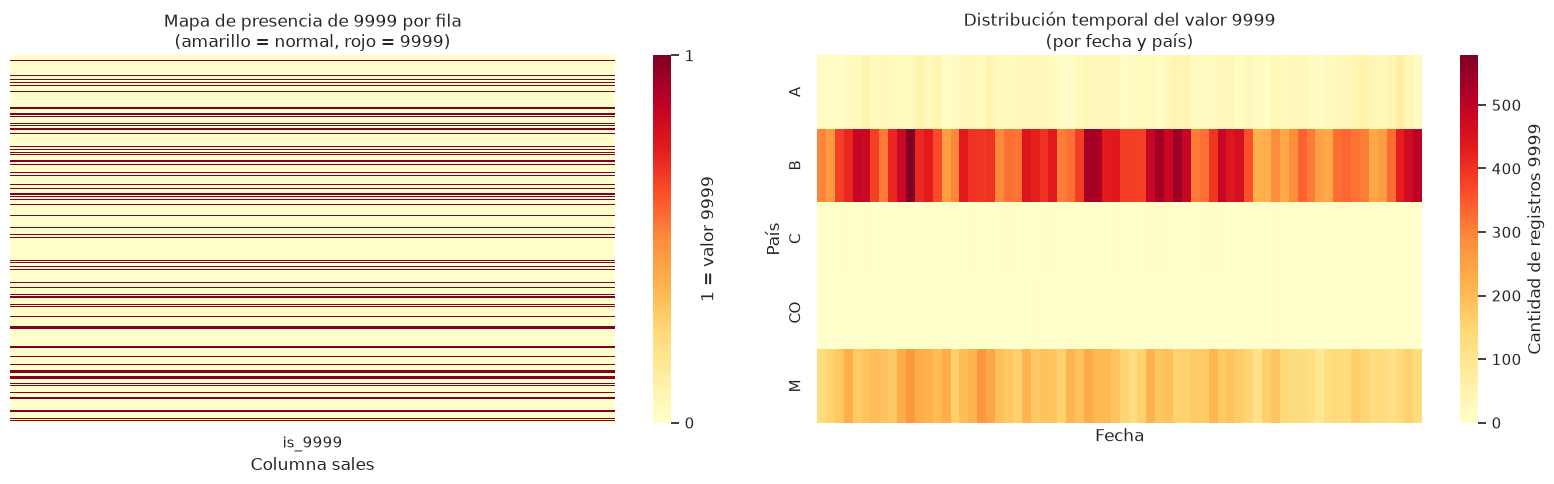

% de filas con 9999 por país:


,country,n_9999,total,pct
0,A,1906,11131,17.12
1,B,25817,148061,17.44
2,C,141,730,19.32
3,CO,59,326,18.10
4,M,11889,67107,17.72


In [12]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El heatmap de presencia replica el estilo del análisis de nulos para hacer
# directamente comparable la distribución de 9999 con la de los valores faltantes.
# El panel temporal revela si el outlier está asociado a fechas concretas
# (falla del sistema) o es un patrón persistente de codificación.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se creó un flag binario `is_9999` (1=outlier, 0=normal). Con este flag se
# construyó un heatmap de presencia por fila (izquierda) usando sns.heatmap() y
# un pivot_table (groupby fecha×país + unstack) para el panel temporal (derecha),
# representando la densidad de ocurrencias del outlier por fecha y país.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Si el panel izquierdo muestra líneas rojas dispersas sin patrón de bloque,
#    el 9999 está distribuido aleatoriamente → confirma flag de codificación.
# 2. Si el panel temporal muestra columnas intensas en fechas concretas, el 9999
#    se concentra en días específicos → posible caída del sistema de registro.
# ──────────────────────────────────────────────────────────────────────────────
sales['is_9999'] = sales['sales'] == 9999

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

heatmap_df = sales[['country', 'zipcode', 'sales', 'is_9999']].copy()
heatmap_df['is_9999'] = heatmap_df['is_9999'].astype(int)  # 1 = es 9999, 0 = normal

sns.heatmap(
    heatmap_df[['is_9999']],
    yticklabels=False,
    cbar=True,
    cmap='YlOrRd',
    ax=axes[0],
    cbar_kws={'label': '1 = valor 9999', 'ticks': [0, 1]}
)
axes[0].set_title('Mapa de presencia de 9999 por fila\n(amarillo = normal, rojo = 9999)')
axes[0].set_xlabel('Columna sales')

pivot_9999 = (
    sales[sales['is_9999']]
    .groupby(['date', 'country'])
    .size()
    .unstack(fill_value=0)
)

if not pivot_9999.empty:
    sns.heatmap(
        pivot_9999.T,
        cmap='YlOrRd',
        linewidths=0,
        ax=axes[1],
        cbar_kws={'label': 'Cantidad de registros 9999'},
        yticklabels=True,
        xticklabels=False
    )
    axes[1].set_title('Distribución temporal del valor 9999\n(por fecha y país)')
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('País')
else:
    axes[1].text(0.5, 0.5, 'Sin valores 9999', ha='center', va='center', fontsize=14)
    axes[1].set_title('Distribución temporal del valor 9999')

plt.tight_layout()
plt.show()

print(f"% de filas con 9999 por país:")
display(
    sales.groupby('country')['is_9999']
    .agg(n_9999='sum', total='count')
    .assign(pct=lambda d: (d['n_9999'] / d['total'] * 100).round(2))
    .reset_index()
)

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El diagnóstico profundo confirma o descarta las hipótesis sobre el 9999:
# ¿es un flag sistemático por producto? ¿Se repite en el mismo producto?
# ¿Sus ventas normales son mucho menores que 9999?
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se filtraron los registros con sales=9999 y se aplicó groupby('product_id').size()
# para detectar repeticiones. Luego se calculó .describe() con percentiles extendidos
# sobre las ventas normales de los mismos productos afectados, y value_counts()
# sobre fechas para encontrar los días con más ocurrencias del outlier.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Los productos que alguna vez tuvieron 9999 presentan ventas normales muy
#    bajas (mediana ≈ 1–3), lo que confirma que 9999 no es una venta real.
# 2. El valor máximo de ventas reales es muy inferior a 9999, por lo que se
#    descarta como dato válido y debe eliminarse del dataset de entrenamiento.
# ──────────────────────────────────────────────────────────────────────────────
df_9999 = sales[sales['sales'] == 9999].copy()

print(f"Total filas con sales=9999: {len(df_9999):,}")
print(f"Productos únicos con 9999 : {df_9999['product_id'].nunique():,}")
print(f"Países con 9999           : {sorted(df_9999['country'].unique())}")
print()

repeat_9999 = df_9999.groupby('product_id').size().rename('veces')
print(f"Productos que tienen 9999 más de una vez: {(repeat_9999 > 1).sum():,}")
print()

products_with_9999 = df_9999['product_id'].unique()
normal_sales_same_product = (
    sales[sales['product_id'].isin(products_with_9999) & (sales['sales'] != 9999)]
    ['sales'].describe(percentiles=[.25, .50, .75, .95, .99])
)
print("Distribución de ventas NORMALES de los mismos productos que alguna vez tuvieron 9999:")
display(normal_sales_same_product.to_frame())

print("\n=== Top 10 fechas con más registros 9999 ===")
display(df_9999['date'].value_counts().head(10).rename_axis('fecha').reset_index(name='n_registros'))

max_normal = sales[sales['sales'] != 9999]['sales'].max()
print(f"\nValor máximo de ventas excluyendo 9999: {max_normal:,.0f}")
print(f"→ {'9999 es claramente un outlier, no un dato real.' if max_normal < 9999 else '9999 puede ser una venta real en algunos casos.'}")

Total filas con sales=9999: 39,812
Productos únicos con 9999 : 907
Países con 9999           : ['A', 'B', 'C', 'CO', 'M']

Productos que tienen 9999 más de una vez: 847

Distribución de ventas NORMALES de los mismos productos que alguna vez tuvieron 9999:


,sales
count,186423.000000
mean,1.272434
std,1.498200
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
95%,3.000000
99%,5.000000
max,200.000000



=== Top 10 fechas con más registros 9999 ===


,fecha,n_registros
0,2024-06-11,871
1,2024-07-01,798
2,2024-07-02,764
3,2024-07-11,746
4,2024-07-09,738
5,2024-07-08,736
6,2024-06-10,733
7,2024-06-06,719
8,2024-07-10,713
9,2024-07-12,694



Valor máximo de ventas excluyendo 9999: 200
→ 9999 es claramente un outlier/centinela, no un dato real.


## 5. Estadísticas Descriptivas

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Se elimina el centinela 9999 para construir el dataset limpio de trabajo.
# Las estadísticas descriptivas con percentiles extendidos permiten entender
# la dispersión real de las ventas y detectar si existen otros valores extremos.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Filtrado booleano `sales['sales'] != 9999` para crear `sales_clean`.
# Se usó .describe() con percentiles [.01, .05, .25, .50, .75, .95, .99]
# para tener una visión completa de las colas de la distribución de ventas.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La mediana de ventas es muy baja (≈ 1–2 unidades), indicando que la mayoría
#    de los registros corresponden a productos de baja rotación diaria.
# 2. El percentil 99 se aleja considerablemente de la mediana, confirmando una
#    distribución con cola derecha muy pesada (heavy tail).
# ──────────────────────────────────────────────────────────────────────────────
sales_clean = sales[sales['sales'] != 9999].copy()

print(f"Filas originales  : {len(sales):,}")
print(f"Filas sin outlier: {len(sales_clean):,}")
print(f"Porcentaje de filas eliminadas por outlier: {(len(sales) - len(sales_clean)) / len(sales) * 100:.2f}%")
print()
print("=== Estadísticas de 'sales' (sin outliers) ===")
display(sales_clean['sales'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).to_frame())
print()

Filas originales  : 227,355
Filas sin centinela: 187,543
Porcentaje de filas eliminadas por centinela: 17.51%

=== Estadísticas de 'sales' (sin centinelas) ===


,sales
count,187232.000000
mean,1.272550
std,1.496167
min,1.000000
1%,1.000000
5%,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
95%,3.000000


In [15]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Analizar la variable categórica 'country' permite cuantificar si el dataset
# está balanceado entre países o si alguno domina abrumadoramente el volumen,
# lo que afectaría la estrategia de modelado por país.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se usó .describe(include='object') para resumen automático de categóricas y
# .value_counts() sobre 'country' para obtener el conteo por país, enriquecido
# con una columna de porcentaje usando assign() con lambda.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Existen pocos países distintos (anonimizados), con distribuciones de
#    registros potencialmente muy distintas entre ellos.
# 2. El país con mayor número de registros concentra la mayor parte del
#    historial de ventas, lo que puede sesgar modelos entrenados globalmente.
# ──────────────────────────────────────────────────────────────────────────────
print("=== Variables categóricas — product_sales ===")
display(sales_clean[['country']].describe(include='object'))

print("\n=== Distribución de registros por país ===")
display(
    sales_clean['country'].value_counts()
    .rename_axis('country')
    .reset_index(name='registros')
    .assign(pct=lambda d: (d['registros'] / d['registros'].sum() * 100).round(2))
)

=== Variables categóricas — product_sales ===


,country
count,187543
unique,5
top,B
freq,122244



=== Distribución de registros por país ===


,country,registros,pct
0,B,122244,65.18
1,M,55218,29.44
2,A,9225,4.92
3,C,589,0.31
4,CO,267,0.14


## 6. Análisis Temporal

Exploramos la evolución de ventas en el tiempo: tendencias diarias, semanales y por país.

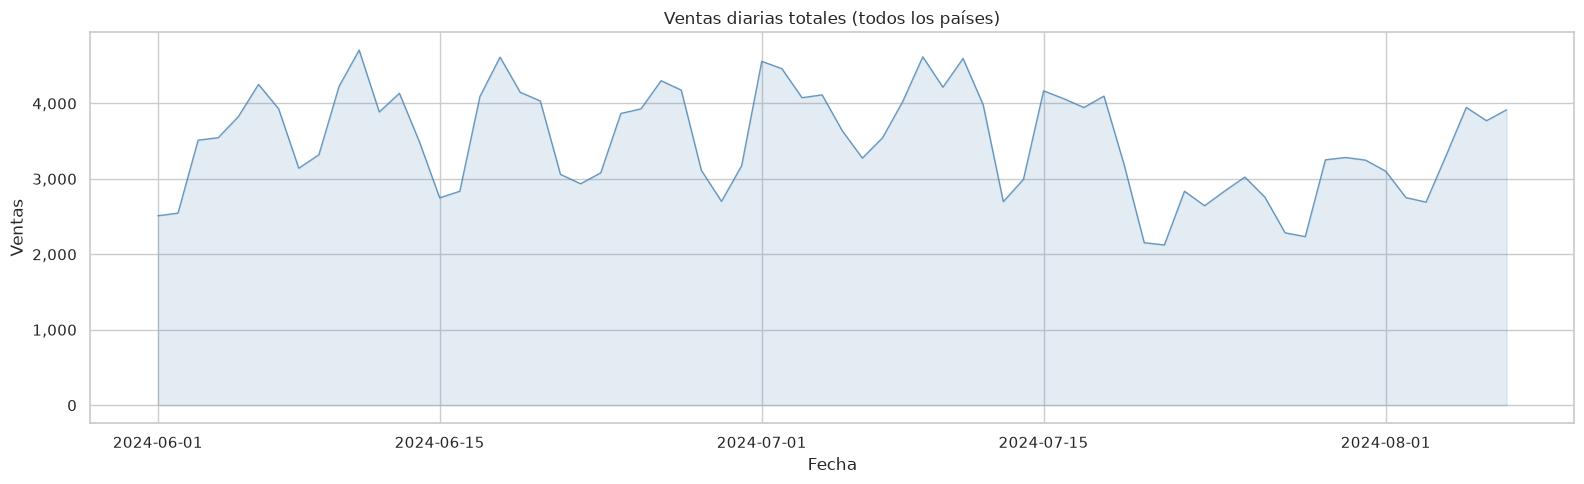

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# La serie temporal de ventas diarias es la visualización más directa de la
# tendencia global. Permite ver si el negocio crece, decrece o es estable
# dentro del período disponible, y detectar caídas o picos anómalos.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se agregaron las ventas con groupby('date').sum() para obtener el total diario.
# Se graficó con ax.plot() + fill_between() para resaltar el área bajo la curva,
# usando FuncFormatter de matplotlib para formatear el eje Y con separador de miles.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. El gráfico revela si existe una tendencia creciente de ventas hacia el
#    final del período, lo que implicaría necesitar modelos con componente de
#    tendencia (no solo media histórica).
# 2. Los picos o caídas abruptas identifican fechas especiales (feriados,
#    eventos de MercadoLibre) que deben considerarse como features en el modelo.
# 3. Existe una clara estacionalidad semanal marcada con bajas en las ventas durane los 
#    fines de semana e incrementos durante los días hábiles, lo que sugiere incluir 
#    variables de día de la semana.
# ──────────────────────────────────────────────────────────────────────────────
daily_sales = (sales_clean
    .groupby('date')['sales']
    .sum()
    .reset_index()
    .rename(columns={'sales': 'total_sales'})
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_sales['date'], daily_sales['total_sales'], linewidth=1, color='steelblue', alpha=0.8)
ax.fill_between(daily_sales['date'], daily_sales['total_sales'], alpha=0.15, color='steelblue')
ax.set_title('Ventas diarias totales (todos los países)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

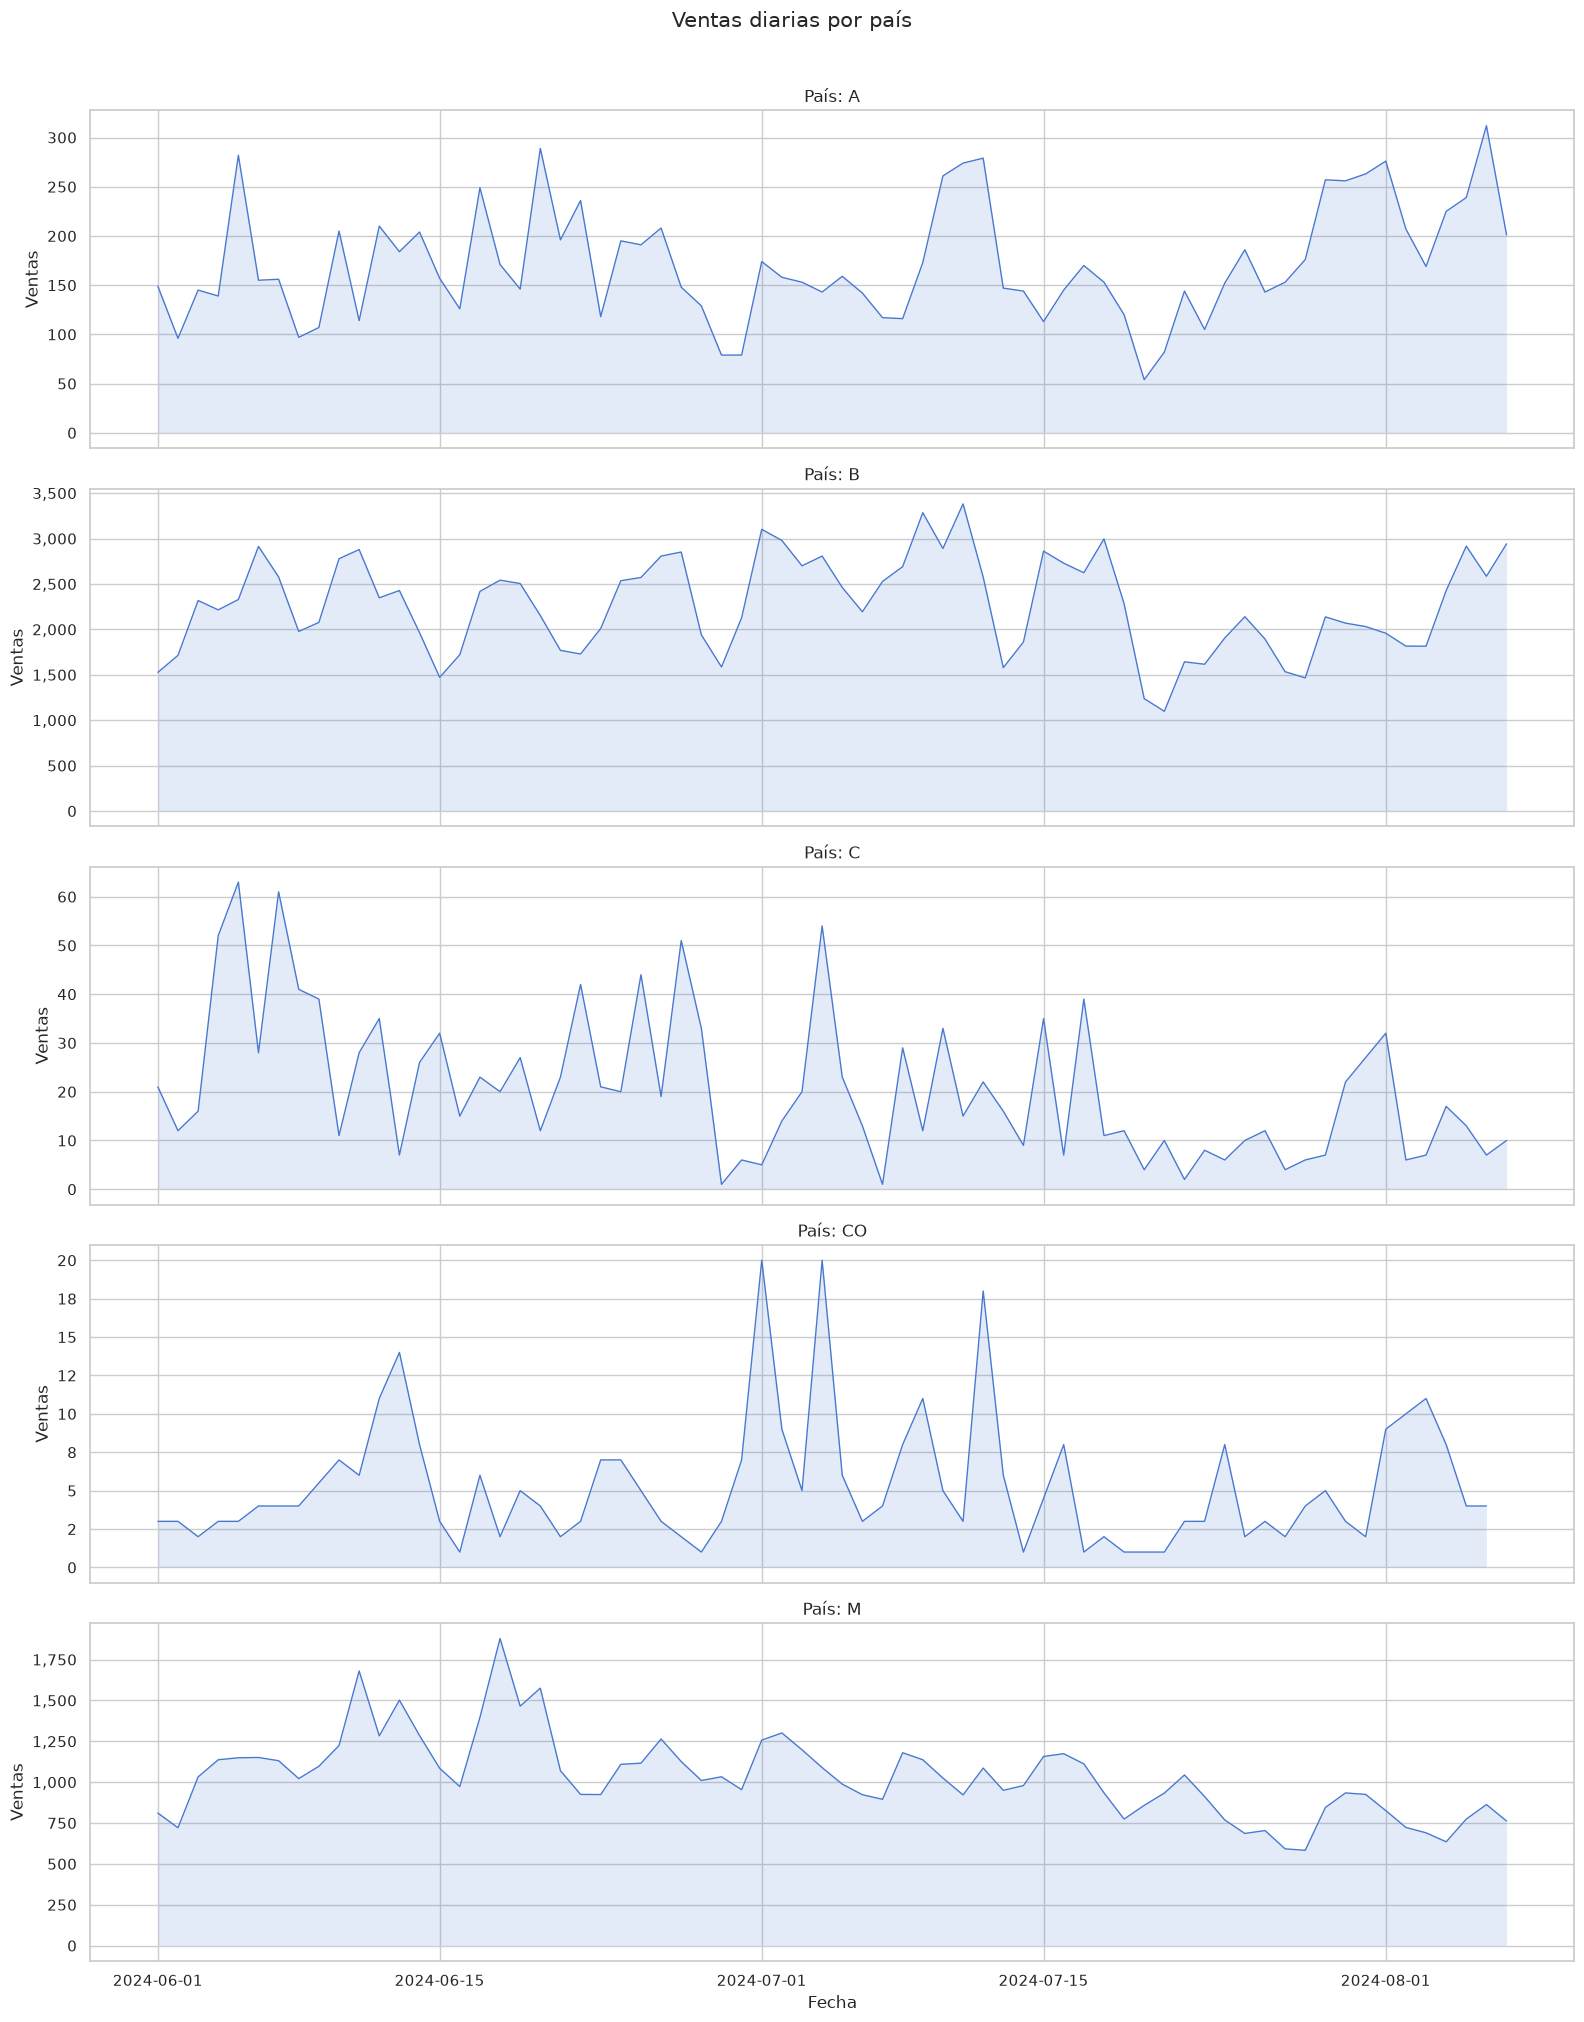

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Separar la serie temporal por país permite detectar si los patrones de
# tendencia y volatilidad son similares o si cada mercado requiere un modelo
# independiente con sus propios parámetros.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se usó groupby(['date','country']).sum() para ventas diarias por país y se
# construyeron subplots facetados (uno por país) con sharex=True para alinear
# los ejes temporales y facilitar la comparación visual entre mercados.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Los países muestran escalas de ventas muy distintas: algunos tienen volumen
#    mucho mayor que otros, lo que sugiere modelos por país separados.
# 2. La forma de la curva (plana, creciente, estacional) varía entre países,
#    confirmando que el comportamiento de demanda no es homogéneo entre mercados.
# ──────────────────────────────────────────────────────────────────────────────
daily_country = (sales_clean
    .groupby(['date', 'country'])['sales']
    .sum()
    .reset_index()
)

countries = sorted(daily_country['country'].unique())
fig, axes = plt.subplots(len(countries), 1, figsize=(16, 4 * len(countries)), sharex=True)
if len(countries) == 1:
    axes = [axes]

for ax, ctry in zip(axes, countries):
    df_c = daily_country[daily_country['country'] == ctry]
    ax.plot(df_c['date'], df_c['sales'], linewidth=1, label=ctry)
    ax.fill_between(df_c['date'], df_c['sales'], alpha=0.15)
    ax.set_title(f'País: {ctry}')
    ax.set_ylabel('Ventas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[-1].set_xlabel('Fecha')
plt.suptitle('Ventas diarias por país', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

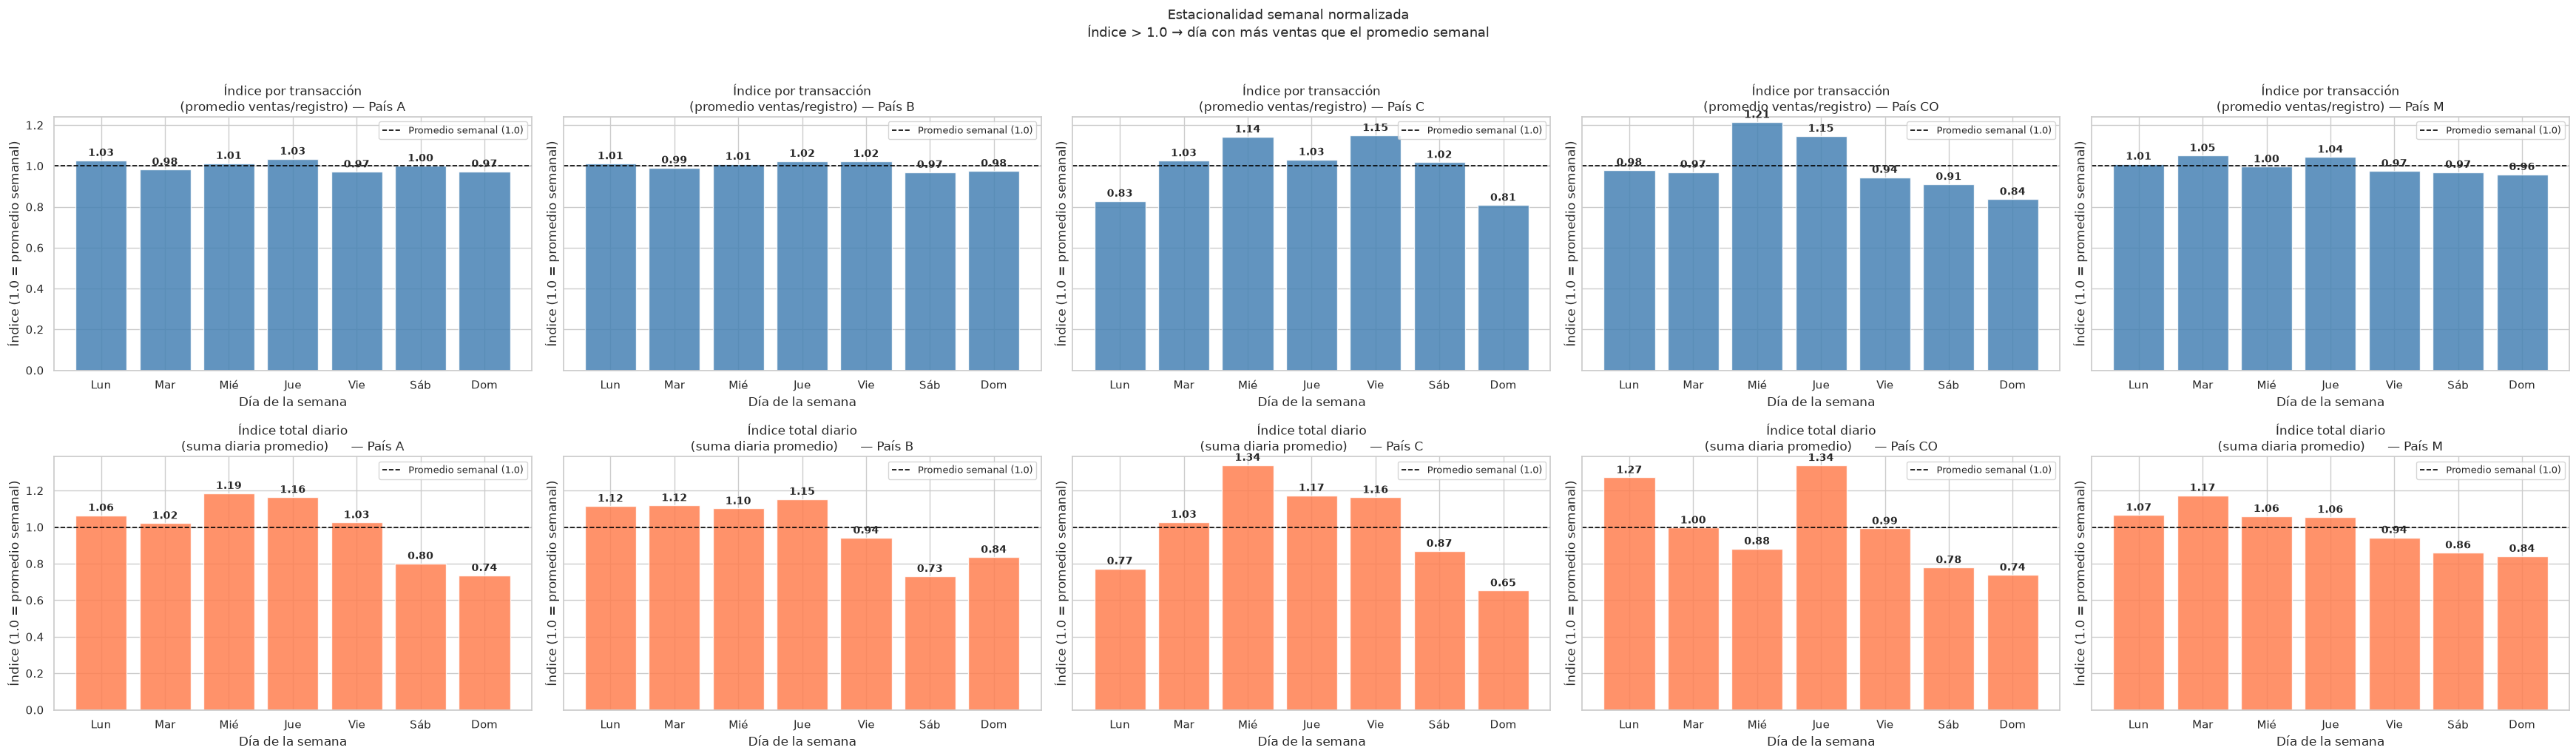

=== Índices de estacionalidad por transacción ===


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
country,,,,,,,
A,1.027,0.982,1.012,1.034,0.971,1.000,0.973
B,1.011,0.991,1.009,1.023,1.022,0.969,0.975
C,0.828,1.025,1.142,1.031,1.149,1.018,0.808
CO,0.980,0.970,1.214,1.146,0.944,0.910,0.837
M,1.009,1.050,0.996,1.043,0.975,0.969,0.958



=== Índices de estacionalidad totales diarios ===


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
country,,,,,,,
A,1.065,1.022,1.186,1.164,1.026,0.801,0.736
B,1.116,1.119,1.102,1.154,0.941,0.732,0.836
C,0.773,1.028,1.340,1.174,1.163,0.869,0.653
CO,1.272,0.997,0.882,1.339,0.992,0.780,0.739
M,1.066,1.174,1.060,1.055,0.943,0.860,0.841


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# La estacionalidad semanal normalizada indica qué días concentran más demanda.
# Usar un índice (valor_día / promedio_semanal) permite comparar países con
# escalas de venta absolutamente distintas en un mismo gráfico.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se calculó el promedio de ventas por día de semana, luego se normalizó con
# groupby.transform('mean') para dividir por la media semanal de cada país,
# obteniendo un índice donde 1.0 = promedio. Se generaron dos vistas: 
#   - por transacción (venta/registro): ¿cuántas unidades lleva el comprador 
#                                       en promedio ese día?
#   - por total diario (suma agregada): ¿cuánto vende el negocio en total ese día?
# Se utiliza gráfico de barras con una línea punteada de referencia en 1.0.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Se distingue claramente si los días de semana o el fin de semana tienen
#    mayor demanda, lo que define el patrón de features cíclicos del modelo.
# 2. Las dos vistas (por transacción vs. total diario) pueden mostrar patrones
#    distintos si ciertos días concentran más productos activos que otros.
# ──────────────────────────────────────────────────────────────────────────────
sales_clean['day_of_week'] = sales_clean['date'].dt.day_name()
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DOW_ES    = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

avg_per_tx = (sales_clean
    .groupby(['country', 'day_of_week'])['sales']
    .mean()
    .reset_index(name='avg_sales')
)
avg_per_tx['weekly_mean'] = avg_per_tx.groupby('country')['avg_sales'].transform('mean')
avg_per_tx['index']       = avg_per_tx['avg_sales'] / avg_per_tx['weekly_mean']
avg_per_tx['day_of_week'] = pd.Categorical(avg_per_tx['day_of_week'], categories=DOW_ORDER, ordered=True)
avg_per_tx = avg_per_tx.sort_values(['country', 'day_of_week'])

daily_total = (sales_clean
    .groupby(['country', 'date', 'day_of_week'])['sales']
    .sum()
    .reset_index(name='daily_sales')
)
avg_total = (daily_total
    .groupby(['country', 'day_of_week'])['daily_sales']
    .mean()
    .reset_index(name='avg_daily_sales')
)
avg_total['weekly_mean'] = avg_total.groupby('country')['avg_daily_sales'].transform('mean')
avg_total['index']       = avg_total['avg_daily_sales'] / avg_total['weekly_mean']
avg_total['day_of_week'] = pd.Categorical(avg_total['day_of_week'], categories=DOW_ORDER, ordered=True)
avg_total = avg_total.sort_values(['country', 'day_of_week'])

countries = sorted(sales_clean['country'].unique())
fig, axes = plt.subplots(2, len(countries), figsize=(7 * len(countries), 10), sharey='row')

if len(countries) == 1:
    axes = axes.reshape(2, 1)

for col, ctry in enumerate(countries):
    for row, (df, title, color) in enumerate([
        (avg_per_tx, f'Índice por transacción\n(promedio ventas/registro) — País {ctry}', 'steelblue'),
        (avg_total,  f'Índice total diario\n(suma diaria promedio)      — País {ctry}', 'coral'),
    ]):
        ax  = axes[row, col]
        df_c = df[df['country'] == ctry].copy()
        bars = ax.bar(DOW_ES, df_c['index'].values, color=color, edgecolor='white', alpha=0.85)
        ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', label='Promedio semanal (1.0)')
        for bar, val in zip(bars, df_c['index'].values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Día de la semana')
        ax.set_ylabel('Índice (1.0 = promedio semanal)')
        ax.set_ylim(0, df_c['index'].max() * 1.18)
        ax.legend(fontsize=9)

plt.suptitle(
    'Estacionalidad semanal normalizada\n'
    'Índice > 1.0 → día con más ventas que el promedio semanal',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

print("=== Índices de estacionalidad por transacción ===")
display(avg_per_tx.pivot(index='country', columns='day_of_week', values='index').round(3))
print("\n=== Índices de estacionalidad totales diarios ===")
display(avg_total.pivot(index='country', columns='day_of_week', values='index').round(3))

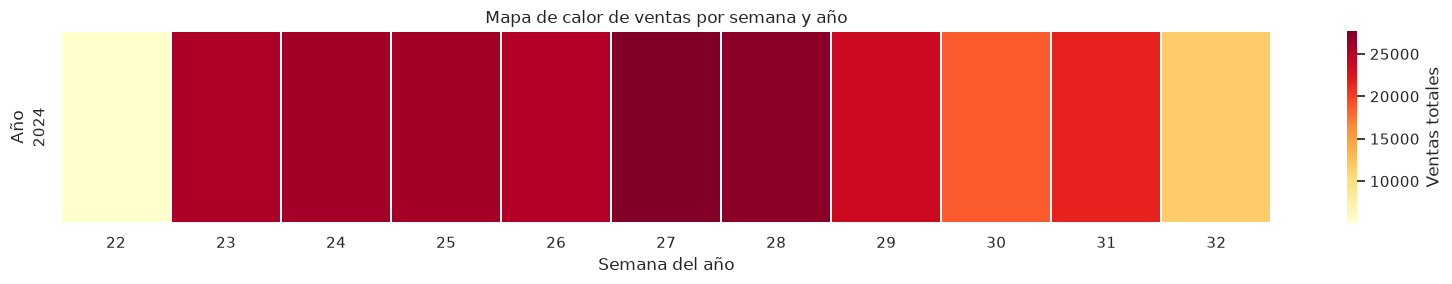

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El heatmap año × semana es una vista de calendario comprimida que revela
# patrones estacionales de mayor escala (eventos de temporada, hot sale, etc.)
# que no son visibles en el gráfico de línea diario.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se extrajo el número de semana ISO con dt.isocalendar().week y el año con
# dt.year. Luego se construyó un pivot table (groupby year+week → unstack) y
# se visualizó con sns.heatmap() usando cmap='YlOrRd' con escala de color
# continua para resaltar semanas de alta y baja actividad.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Las semanas con color más intenso corresponden a picos de ventas
#    recurrentes, lo que puede guiar la ingeniería de features temporales.
# 2. Con solo ~2 meses de datos las filas del heatmap son pocas, limitando la
#    detección de patrones anuales: se necesitaría más historial para confirmarlos.
# ──────────────────────────────────────────────────────────────────────────────
sales_clean['week'] = sales_clean['date'].dt.isocalendar().week.astype(int)
sales_clean['year'] = sales_clean['date'].dt.year

pivot_week = (sales_clean
    .groupby(['year', 'week'])['sales']
    .sum()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 3 * len(pivot_week)))
sns.heatmap(pivot_week, cmap='YlOrRd', linewidths=0.3,
            fmt='.0f', ax=ax, cbar_kws={'label': 'Ventas totales'})
ax.set_title('Mapa de calor de ventas por semana y año')
ax.set_xlabel('Semana del año')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()

## 7. Análisis por Producto

Analizamos cuántos registros, días observados y ventas tiene cada producto.

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Agregar estadísticas por producto permite identificar qué tan bien observado
# está cada ítem. Esta información es crítica para decidir la estrategia de
# forecast: modelos individuales vs. agrupados vs. fallback por media global.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se usó groupby('product_id').agg() con un diccionario de métricas (count, nunique,
# sum, mean, max, min). Se complementó con .describe() con percentiles extendidos
# para visualizar la distribución completa de días observados y ventas por producto.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La mayoría de los productos tienen muy pocos días de observación (mediana
#    baja), lo que confirma el problema de cold start a gran escala.
# 2. La dispersión entre venta_min y venta_max dentro de un mismo producto
#    indica alta variabilidad diaria, lo que complica el forecast puntual.
# ──────────────────────────────────────────────────────────────────────────────
product_stats = (sales_clean
    .groupby('product_id')
    .agg(
        n_registros  = ('sales', 'count'),
        dias_obs     = ('date', 'nunique'),
        venta_total  = ('sales', 'sum'),
        venta_media  = ('sales', 'mean'),
        venta_max    = ('sales', 'max'),
        venta_min    = ('sales', 'min'),
    )
    .reset_index()
)

print(f"Total de productos: {len(product_stats):,}")
print()
display(product_stats.describe(percentiles=[.25, .50, .75, .95, .99]))

Total de productos: 985



,n_registros,dias_obs,venta_total,venta_media,venta_max,venta_min
count,985.000000,985.000000,985.000000,984.000000,984.000000,984.000000
mean,190.083249,26.795939,241.890355,1.272716,5.162602,1.013211
std,500.042540,19.506096,677.056734,0.522309,11.711607,0.182746
min,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,20.000000,10.000000,23.000000,1.000000,1.000000,1.000000
50%,55.000000,21.000000,70.000000,1.082889,2.000000,1.000000
75%,180.000000,41.000000,209.000000,1.307178,5.000000,1.000000
95%,758.600000,65.000000,992.600000,2.192340,15.000000,1.000000
99%,1762.360000,68.000000,2432.560000,3.674762,36.510000,1.000000
max,8083.000000,68.000000,14226.000000,6.456897,200.000000,5.000000


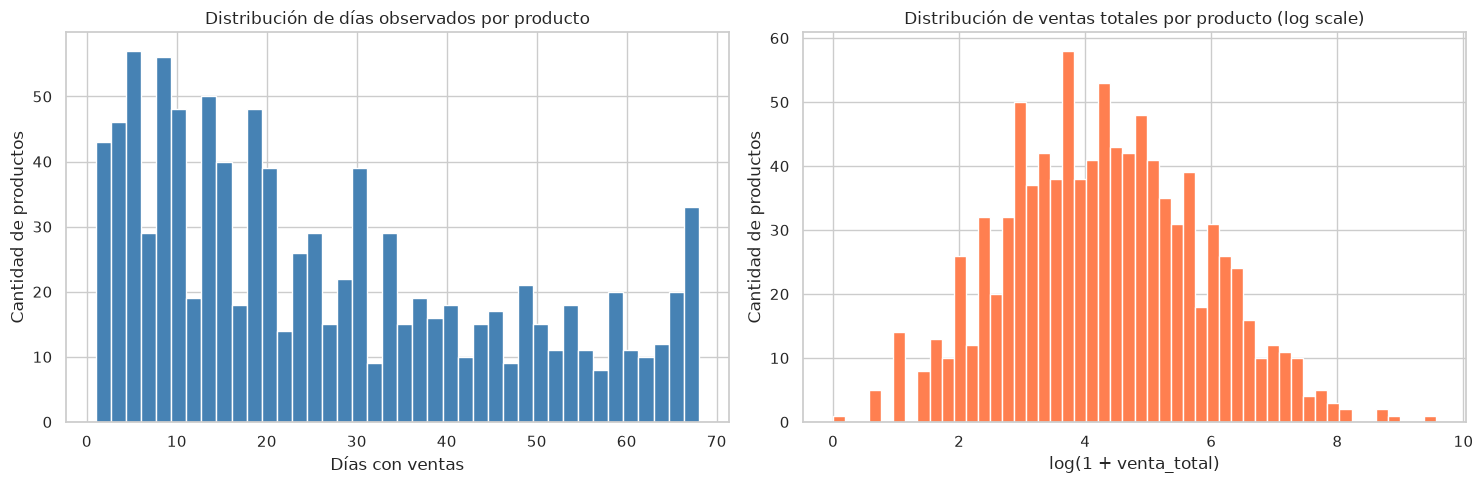


Productos con <= 3 días observados: 63
Productos con <= 7 días observados: 175
Productos con >= 30 días observados: 386


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Los histogramas de días observados y ventas totales (en escala log) muestran
# la distribución del historial disponible por producto, identificando qué
# proporción enfrenta cold-start y cuáles son los productos más vendidos.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se graficaron dos histogramas en subplots: el primero sobre 'dias_obs' (escala
# lineal) y el segundo sobre np.log1p('venta_total') para comprimir la cola
# derecha y revelar la forma subyacente de la distribución.
# Se complementó con conteos de umbral (<=3, <=7, >=30 días) para cuantificar
# los segmentos críticos del cold-start.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La mayoría de los productos se agrupan en pocos días de observación,
#    confirmando que el problema de cold-start afecta a gran parte del catálogo.
# 2. La distribución log de ventas totales muestra una forma aproximadamente
#    normal en esa escala, validando el uso de transformación log en el modelo.
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(product_stats['dias_obs'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de días observados por producto')
axes[0].set_xlabel('Días con ventas')
axes[0].set_ylabel('Cantidad de productos')

axes[1].hist(np.log1p(product_stats['venta_total']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución de ventas totales por producto (log scale)')
axes[1].set_xlabel('log(1 + venta_total)')
axes[1].set_ylabel('Cantidad de productos')

plt.tight_layout()
plt.show()

print(f"\nProductos con <= 3 días observados: {(product_stats['dias_obs'] <= 3).sum():,}")
print(f"Productos con <= 7 días observados: {(product_stats['dias_obs'] <= 7).sum():,}")
print(f"Productos con >= 30 días observados: {(product_stats['dias_obs'] >= 30).sum():,}")

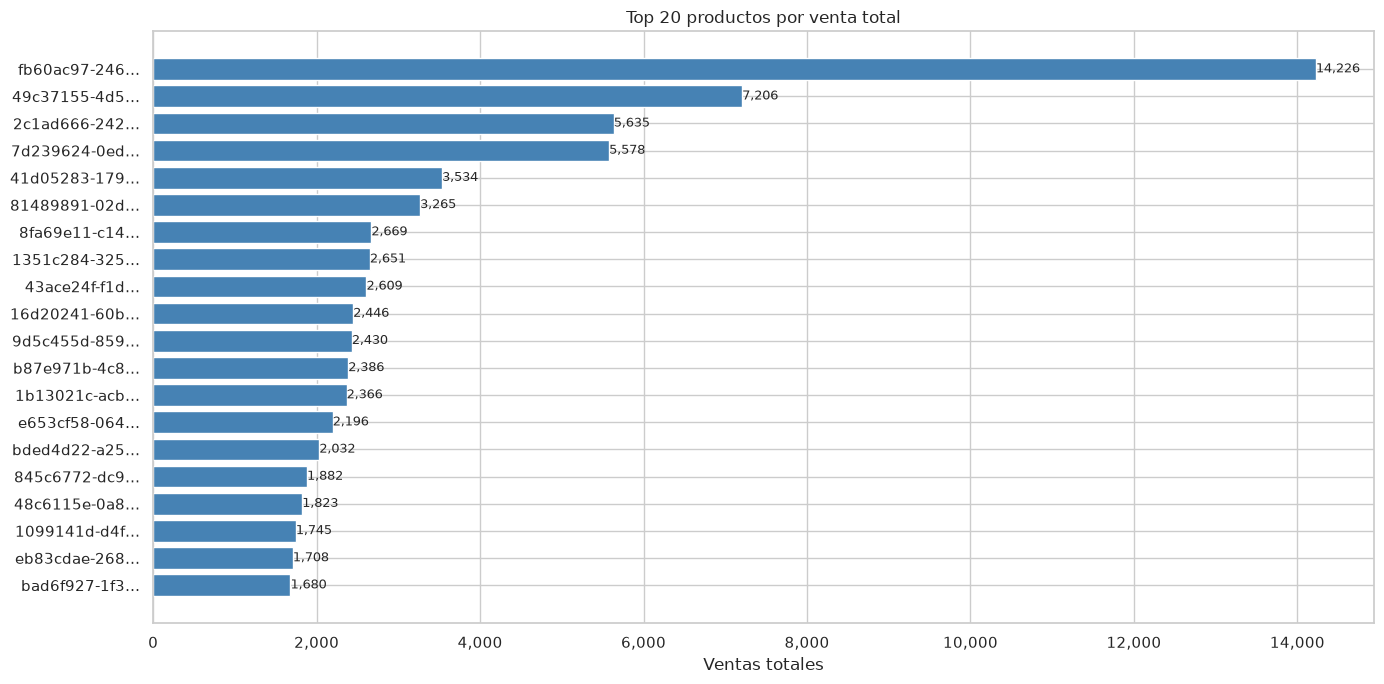

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El ranking de top 20 productos muestra qué ítems concentran la mayor parte
# del volumen total. Permite identificar si el catálogo sigue una distribución
# tipo Pareto (pocos productos generan la mayoría de las ventas).
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se extrajo el top 20 con nlargest(20, 'venta_total') y se visualizó con
# un gráfico de barras horizontales (ax.barh() + invert_yaxis()) para facilitar
# la lectura de los IDs. Se añadieron etiquetas de valor directamente sobre
# cada barra con ax.text() para lectura precisa de magnitudes.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La distribución es altamente concentrada: los top productos tienen órdenes
#    de magnitud más ventas que la media, confirmando la ley de Pareto.
# 2. Para estos productos de alto volumen sí es viable construir modelos
#    individuales con suficiente historia; el resto requiere estrategias grupales.
# ──────────────────────────────────────────────────────────────────────────────
top20_products = product_stats.nlargest(20, 'venta_total')

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    [pid[:12] + '…' for pid in top20_products['product_id']],
    top20_products['venta_total'],
    color='steelblue'
)
ax.invert_yaxis()
ax.set_title('Top 20 productos por venta total')
ax.set_xlabel('Ventas totales')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, top20_products['venta_total']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Análisis del Archivo Geo y Asignación de Ciudades

Aquí entendemos cómo se mapean los zipcodes a ciudades mediante rangos, y luego hacemos el join con `product_sales`.

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Antes de hacer el join, es importante entender la estructura de geo.csv:
# cuántas ciudades hay por país y cuán "grandes" son los rangos de zipcode.
# Esto determina la granularidad geográfica del forecast.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se usó groupby('country')['city'].nunique() para contar ciudades únicas y
# groupby(['country','city']).size() para ver rangos por ciudad.
# Se calculó la amplitud de cada rango como e_zipcode - s_zipcode y se
# describió con .describe() con percentiles para medir la variabilidad geográfica.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. El número de ciudades por país varía significativamente, reflejando
#    diferencias en la cobertura geográfica de cada mercado.
# 2. Algunos rangos de zipcode son muy amplios (alta amplitud), lo que implica
#    que muchos productos diferentes quedarán asignados a la misma ciudad.
# ──────────────────────────────────────────────────────────────────────────────
print("=== Ciudades únicas por país ===")
display(geo.groupby('country')['city'].nunique().rename('ciudades_unicas').reset_index())

print("\n=== Rangos de zipcode por ciudad (top 20) ===")
display(geo.groupby(['country','city']).size().rename('n_rangos').reset_index()
         .sort_values('n_rangos', ascending=False).head(20))

geo['rango_amplitud'] = geo['e_zipcode'] - geo['s_zipcode']
print("\n=== Estadísticas de amplitud de rangos ===")
display(geo['rango_amplitud'].describe(percentiles=[.25, .50, .75, .95, .99]))

=== Ciudades únicas por país ===


,country,ciudades_unicas
0,B,3
1,M,5



=== Rangos de zipcode por ciudad (top 20) ===


,country,city,n_rangos
5,M,M3,4182
4,M,M2,1903
2,B,B3,1717
6,M,M4,1543
0,B,B1,512
7,M,M5,506
1,B,B2,246
3,M,M1,196



=== Estadísticas de amplitud de rangos ===


count    1.080500e+04
mean     9.264229e+03
std      8.191222e+04
min      0.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      5.200000e+01
95%      3.000000e+04
99%      1.500000e+05
max      3.440990e+06
Name: rango_amplitud, dtype: float64

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# La asignación de ciudad se hace mediante un join por rango (zipcode entre
# s_zipcode y e_zipcode). Se itera por país para reducir el espacio de búsqueda.
# El % de match resultante determina cuántos registros pueden usarse en el modelo.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se implementó la función assign_city() que agrupa por país (groupby), luego
# itera sobre las filas de geo para construir una máscara booleana
# (zipcode >= s_zipcode) & (zipcode <= e_zipcode) y asigna la ciudad al match.
# El resultado se concatena con pd.concat() para reconstruir el DataFrame completo.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La mayoría de los registros logran asignarse a una ciudad, validando que
#    los rangos de geo.csv cubren bien los zipcodes de product_sales.
# 2. Los registros sin match quedan excluidos del forecast; si son muchos,
#    habría que investigar si sus zipcodes están truncados o tienen otro formato.
# ──────────────────────────────────────────────────────────────────────────────
def assign_city(sales_df: pd.DataFrame, geo_df: pd.DataFrame) -> pd.DataFrame:
    """Asigna la ciudad correspondiente a cada fila según el zipcode y país."""
    result_parts = []
    for ctry, grp in sales_df.groupby('country'):
        geo_ctry = geo_df[geo_df['country'] == ctry].copy()
        merged = grp.copy()
        merged['city'] = None
        for _, geo_row in geo_ctry.iterrows():
            mask = (merged['zipcode'] >= geo_row['s_zipcode']) & \
                   (merged['zipcode'] <= geo_row['e_zipcode'])
            merged.loc[mask, 'city'] = geo_row['city']
        result_parts.append(merged)
    return pd.concat(result_parts, ignore_index=True)

print("Asignando ciudades... (puede tardar unos segundos)")
sales_geo = assign_city(sales_clean, geo)

matched   = sales_geo['city'].notna().sum()
unmatched = sales_geo['city'].isna().sum()
print(f"\nRegistros con ciudad asignada : {matched:,} ({matched/len(sales_geo)*100:.1f}%)")
print(f"Registros sin ciudad (no match): {unmatched:,} ({unmatched/len(sales_geo)*100:.1f}%)")

Asignando ciudades... (puede tardar unos segundos)

Registros con ciudad asignada : 177,421 (94.6%)
Registros sin ciudad (no match): 10,122 (5.4%)


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Investigar los zipcodes que no encontraron match permite cuantificar la
# pérdida de datos y decidir si es necesario ampliar geo.csv o aplicar
# una estrategia de imputación geográfica alternativa.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se filtraron los registros con city.isna() para aislar los no-matches.
# Se usó value_counts() por país para cuantificar la pérdida por mercado y
# drop_duplicates() sobre pares (country, zipcode) para listar los zipcodes
# únicos sin cobertura y comparar su magnitud con los que sí matchean.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Los registros sin ciudad se concentran en uno o pocos países, lo que sugiere
#    que ciertos mercados tienen cobertura geográfica incompleta en geo.csv.
# 2. Los zipcodes sin asignación tienen magnitudes distintas a los que sí matchean,
#    indicando que podrían estar en un formato diferente (truncados o con offset).
# ──────────────────────────────────────────────────────────────────────────────
if unmatched > 0:
    unmatched_df = sales_geo[sales_geo['city'].isna()]
    print("=== Distribución de registros sin ciudad por país ===")
    display(unmatched_df['country'].value_counts().rename_axis('country').reset_index(name='sin_ciudad'))
    print("\n=== Ejemplos de zipcodes sin asignación ===")
    display(unmatched_df[['country', 'zipcode']].drop_duplicates().head(20))

=== Distribución de registros sin ciudad por país ===


,country,sin_ciudad
0,A,9225
1,C,589
2,CO,267
3,B,26
4,M,15



=== Ejemplos de zipcodes sin asignación ===


,country,zipcode
0,A,5152.0
1,A,5172.0
2,A,8322.0
3,A,3020.0
4,A,1878.0
5,A,3170.0
6,A,8324.0
7,A,2400.0
8,A,8307.0
9,A,6621.0


## 9. Análisis por Ciudad

Una vez asignada la columna `city`, analizamos la demanda agregada y la distribución de productos por ciudad.

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Agregar ventas totales por ciudad permite identificar los mercados más
# relevantes del dataset y decidir dónde enfocar los esfuerzos de modelado.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se filtró sales_geo para quedarse solo con registros con ciudad asignada.
# Se aplicó groupby(['country','city']).agg() calculando suma, nunique (productos),
# count (registros) y mean (venta promedio), ordenando por venta_total descendente.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Pocas ciudades concentran la mayor parte de las ventas totales, siguiendo
#    nuevamente una distribución tipo Pareto a nivel geográfico.
# 2. La columna n_productos revela cuáles ciudades tienen mayor diversidad de
#    catálogo, lo que afecta la complejidad del problema de forecast.
# ──────────────────────────────────────────────────────────────────────────────
sales_with_city = sales_geo[sales_geo['city'].notna()].copy()

city_stats = (sales_with_city
    .groupby(['country', 'city'])
    .agg(
        venta_total    = ('sales', 'sum'),
        n_productos    = ('product_id', 'nunique'),
        n_registros    = ('sales', 'count'),
        venta_media    = ('sales', 'mean'),
    )
    .reset_index()
    .sort_values('venta_total', ascending=False)
)

print(f"Ciudades con ventas: {city_stats['city'].nunique()}")
display(city_stats.head(20))

Ciudades con ventas: 8


,country,city,venta_total,n_productos,n_registros,venta_media
2,B,B3,122469.0,557,96003,1.275679
5,M,M3,37558.0,330,29280,1.282719
0,B,B1,16808.0,453,13410,1.253393
1,B,B2,15240.0,454,12593,1.210196
4,M,M2,14760.0,309,11373,1.297811
6,M,M4,10970.0,291,8937,1.227481
7,M,M5,4250.0,246,3307,1.285153
3,M,M1,2710.0,230,2214,1.224029


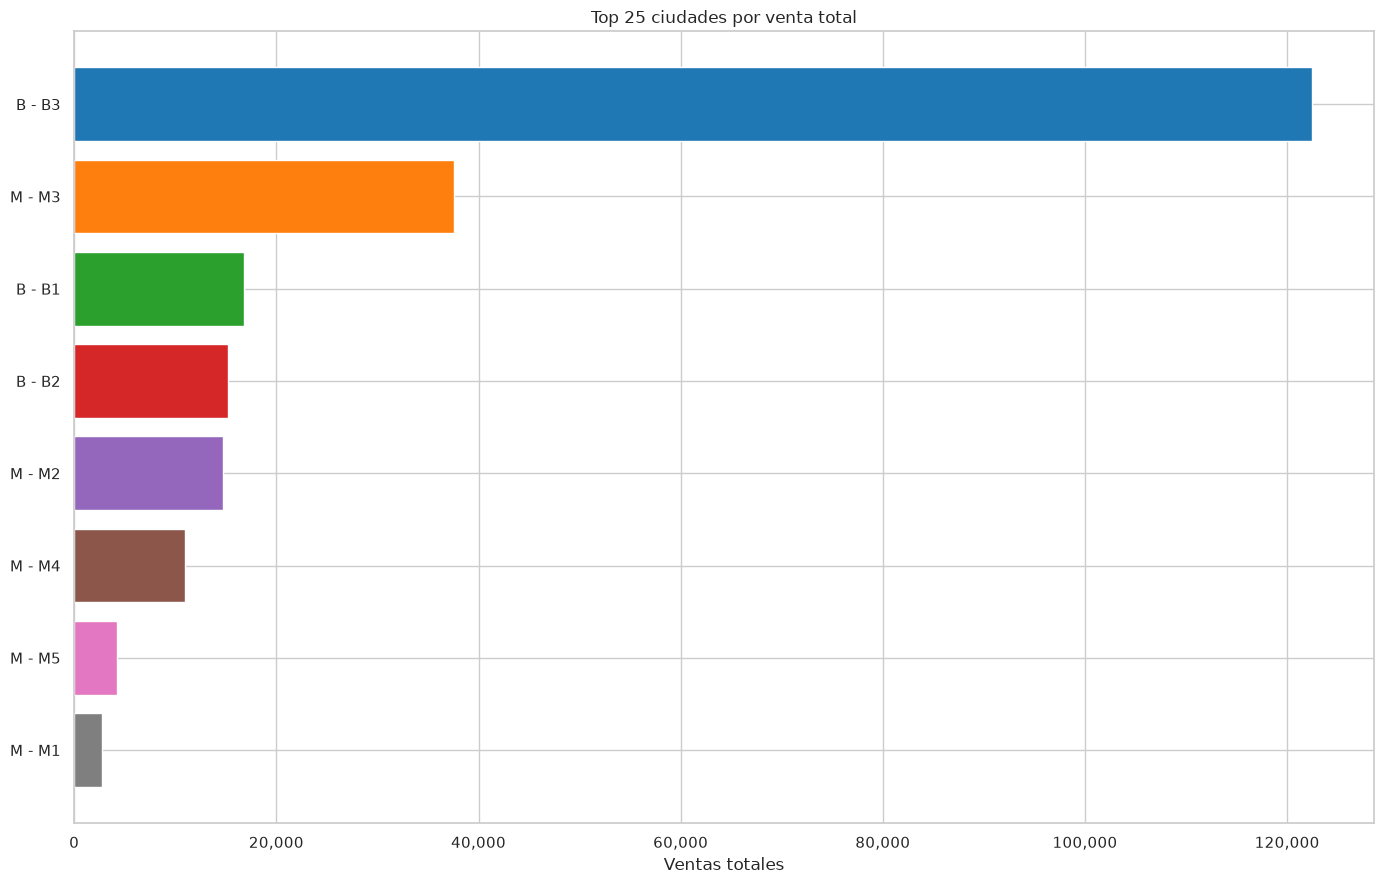

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El gráfico de barras horizontales facilita la lectura del ranking de ciudades
# y revela de forma inmediata la concentración de ventas entre las top ciudades.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se extrajo el top 25 con nlargest(25, 'venta_total') y se visualizó con
# ax.barh() + invert_yaxis(). Se usó una paleta de colores 'tab10' de seaborn
# para diferenciar visualmente las barras por país mediante color.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Las primeras ciudades del ranking acumulan una fracción desproporcionada
#    de las ventas totales, confirmando la concentración geográfica de la demanda.
# 2. Las ciudades en posiciones bajas del top 25 tienen volúmenes muy similares
#    entre sí, lo que indica una "cola larga" de ciudades pequeñas.
# ──────────────────────────────────────────────────────────────────────────────
top25_cities = city_stats.nlargest(25, 'venta_total')

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(
    top25_cities['country'] + ' - ' + top25_cities['city'],
    top25_cities['venta_total'],
    color=sns.color_palette('tab10', len(top25_cities))
)
ax.invert_yaxis()
ax.set_title('Top 25 ciudades por venta total')
ax.set_xlabel('Ventas totales')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

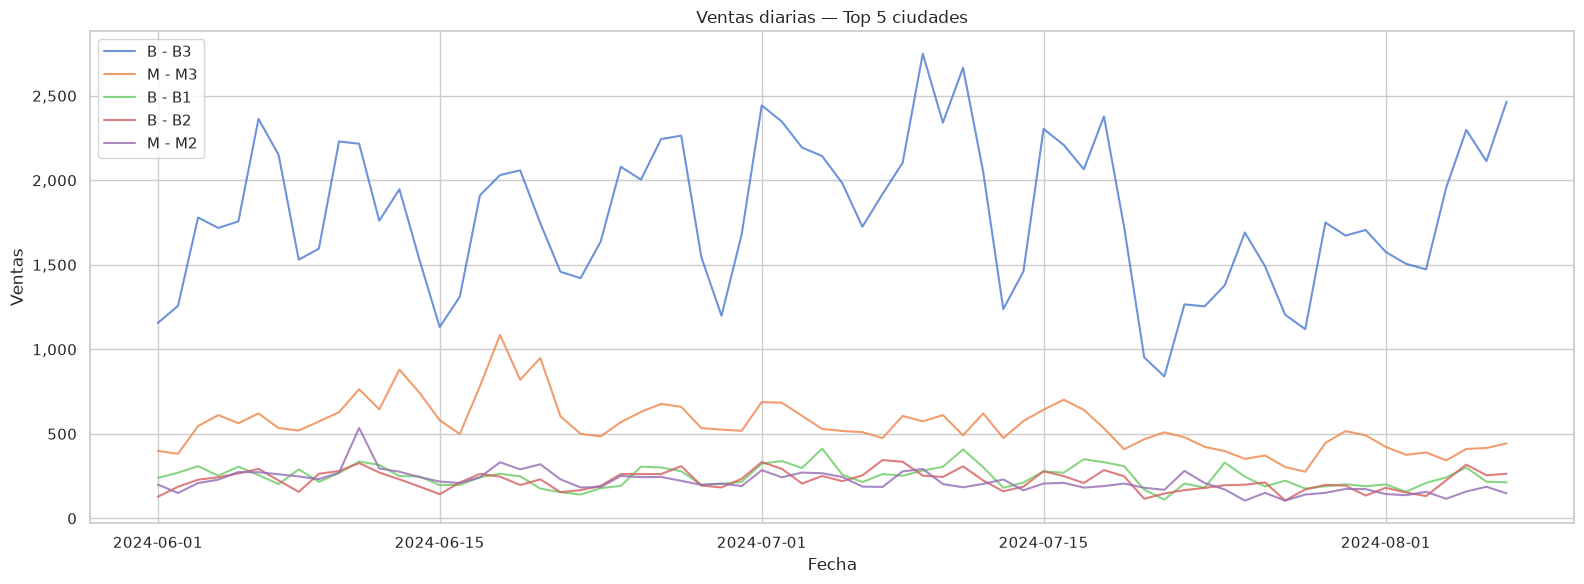

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Ver la evolución temporal de las ciudades más vendedoras permite detectar si
# su tendencia es creciente, estable o si hay picos estacionales compartidos,
# lo que guía la decisión de usar modelos jerárquicos o independientes.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se seleccionaron las top 5 ciudades con nlargest(5, 'venta_total') y se
# calculó la venta diaria con groupby(['date','country','city']).sum().
# Se graficaron con ax.plot() en un único panel multilinea para comparar
# tendencias y picos simultáneos entre las ciudades de mayor volumen.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Algunas ciudades muestran un volumen claramente superior y sostenido,
#    mientras otras tienen picos puntuales, sugiriendo demanda de distinta naturaleza.
# 2. Las series de distintas ciudades presentan picos simultáneos en las mismas
#    fechas, indicando que eventos globales (ej: descuentos) afectan a todos.
# ──────────────────────────────────────────────────────────────────────────────
top5_cities = city_stats.nlargest(5, 'venta_total')[['country','city']].values.tolist()

daily_city = (sales_with_city
    .groupby(['date', 'country', 'city'])['sales']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(16, 6))
for ctry, city in top5_cities:
    df_c = daily_city[(daily_city['country'] == ctry) & (daily_city['city'] == city)]
    ax.plot(df_c['date'], df_c['sales'], label=f'{ctry} - {city}', linewidth=1.5, alpha=0.8)

ax.set_title('Ventas diarias — Top 5 ciudades')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 10. Análisis de Granularidad del Forecast: product_id × city

El objetivo del forecast es a nivel `product_id` × `city`. Aquí analizamos cuántas combinaciones existen y qué tan densas son en el tiempo.

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Analizar las combinaciones product_id × city es la unidad exacta del forecast.
# Conocer cuántas combinaciones existen y qué tan densa es su historia temporal
# determina directamente la viabilidad de los modelos a aplicar.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se usó groupby(['product_id','city']).agg() con métricas de: días únicos
# (nunique), suma, media y fechas mínima/máxima de observación. El .describe()
# con percentiles extendidos revela la distribución de densidad de historia
# y la vida útil observada de cada combo.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. El número de combos es muy alto y con días observados medianos bajos,
#    confirmando que el problema de cold start es estructural en este dataset.
# 2. La diferencia entre primera y última observación por combo revela que muchos
#    productos son efímeros o estacionales, lo que complica el forecast.
# ──────────────────────────────────────────────────────────────────────────────
combo_stats = (sales_with_city
    .groupby(['product_id', 'city'])
    .agg(
        dias_obs    = ('date', 'nunique'),
        venta_total = ('sales', 'sum'),
        venta_media = ('sales', 'mean'),
        primera_obs = ('date', 'min'),
        ultima_obs  = ('date', 'max'),
    )
    .reset_index()
)

print(f"Combinaciones product_id × city: {len(combo_stats):,}")
print()
display(combo_stats.describe(percentiles=[.25, .50, .75, .95, .99]))

Combinaciones product_id × city: 2,870



,dias_obs,venta_total,venta_media,primera_obs,ultima_obs
count,2870.000000,2870.000000,2869.000000,2870,2870
mean,13.982927,78.315331,1.241491,2024-06-12 18:22:19.651568,2024-07-21 21:03:23.205575
min,1.000000,0.000000,1.000000,2024-06-01 00:00:00,2024-06-01 00:00:00
25%,3.000000,5.000000,1.000000,2024-06-02 00:00:00,2024-07-12 00:00:00
50%,8.000000,16.000000,1.008547,2024-06-07 00:00:00,2024-07-29 00:00:00
75%,19.000000,53.000000,1.245902,2024-06-18 00:00:00,2024-08-06 00:00:00
95%,51.000000,294.000000,2.076923,2024-07-15 00:00:00,2024-08-07 00:00:00
99%,66.000000,1034.340000,3.500000,2024-08-01 00:00:00,2024-08-07 00:00:00
max,68.000000,11214.000000,30.000000,2024-08-07 00:00:00,2024-08-07 00:00:00
std,15.723564,322.302347,0.747401,NaN,NaN


=== Combinaciones por densidad temporal ===


,rango,n_combos,pct
0,1-3 días,865,30.1
1,4-7 días,560,19.5
2,8-14 días,524,18.3
3,15-30 días,496,17.3
4,>30 días,425,14.8


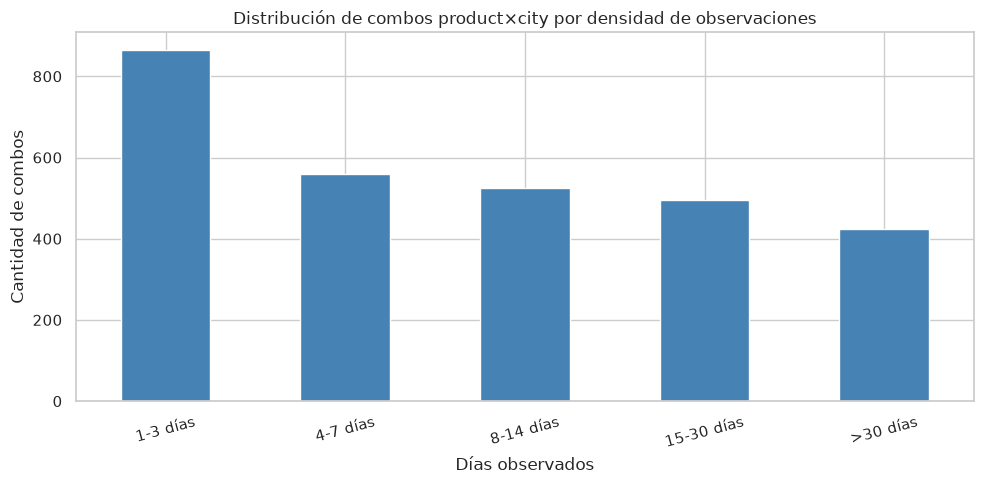

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Clasificar los combos según la densidad de días observados permite segmentar
# el catálogo en grupos con distintas estrategias de forecast:
# series densas (modelos propios) vs. series dispersas (fallback/media global).
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se utilizó pd.cut() con los mismos bins que usa el pipeline en evaluate():
# [0, 7, 30, ∞] → sparse / medium / dense, para que los segmentos del EDA
# sean directamente comparables con las métricas de evaluación del modelo.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La mayoría de los combos cae en la categoría sparse (≤7 días),
#    lo que confirma que el cold start es el caso dominante, no la excepción.
# 2. Solo una fracción pequeña tiene más de 30 días de historia, lo que limita
#    severamente el uso de modelos de series temporales clásicos (ARIMA, Prophet).
# ──────────────────────────────────────────────────────────────────────────────
# Bins alineados con los tiers del pipeline (forecast_pipeline.py → evaluate())
bins   = [0, 7, 30, float('inf')]
labels = ['sparse (≤7d)', 'medium (8-30d)', 'dense (>30d)']
combo_stats['densidad'] = pd.cut(combo_stats['dias_obs'], bins=bins, labels=labels)

density_summary = combo_stats['densidad'].value_counts().sort_index()
print("=== Combinaciones por densidad temporal ===")
display(density_summary.rename_axis('rango').reset_index(name='n_combos')
        .assign(pct=(density_summary / density_summary.sum() * 100).round(1).values))

fig, ax = plt.subplots(figsize=(10, 5))
density_summary.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución de combos product×city por densidad de observaciones')
ax.set_xlabel('Tier de densidad')
ax.set_ylabel('Cantidad de combos')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 11. Detección de Outliers en Ventas

Usamos el método IQR y Z-score para identificar valores atípicos en la columna `sales`.

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El método IQR es robusto ante distribuciones no normales y detecta outliers
# sin asumir ninguna distribución. Z-score complementa identificando valores
# extremos en términos de desviaciones estándar.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# IQR: se calcularon Q1 y Q3 con .quantile(), se derivó el rango intercuartílico
# y se establecieron límites inferior/superior con el factor 1.5×IQR.
# Z-score: se usó scipy.stats.zscore() sobre la columna sales y se marcaron
# los registros con |z| > 3 como outliers. Ambos métodos se comparan en conteo
# y porcentaje para evaluar su sensibilidad.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. El límite superior del IQR es bajo, lo que indica que incluso valores
#    moderados (ej: 10-20 unidades) ya se clasifican como outliers por este método.
# 2. Z-score y IQR coinciden en que existe una proporción relevante de outliers,
#    todos por exceso (cola derecha), coherente con la distribución heavy-tail.
# ──────────────────────────────────────────────────────────────────────────────
# ── Método IQR ────────────────────────────────────────────────────────────────
Q1 = sales_clean['sales'].quantile(0.25)
Q3 = sales_clean['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr = sales_clean[(sales_clean['sales'] < lower_iqr) | (sales_clean['sales'] > upper_iqr)]

# ── Método Z-score ─────────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(sales_clean['sales'].dropna()))
outliers_z = sales_clean.iloc[np.where(z_scores > 3)[0]]

print(f"IQR   — Límite inferior: {lower_iqr:.1f}  |  Límite superior: {upper_iqr:.1f}")
print(f"IQR   — Outliers: {len(outliers_iqr):,} ({len(outliers_iqr)/len(sales_clean)*100:.2f}%)")
print()
print(f"Z>3   — Outliers: {len(outliers_z):,} ({len(outliers_z)/len(sales_clean)*100:.2f}%)")

IQR   — Límite inferior: 1.0  |  Límite superior: 1.0
IQR   — Outliers: 24,699 (13.17%)

Z>3   — Outliers: 1,800 (0.96%)


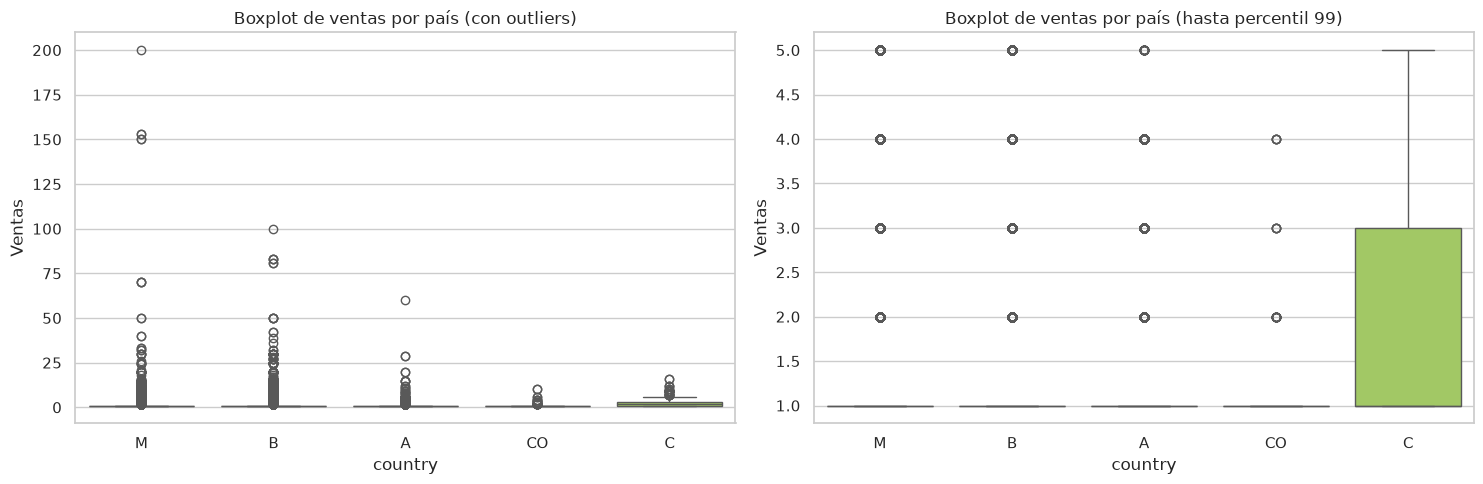

=== Top 10 valores de ventas más altos ===


,country,product_id,date,zipcode,sales
219225,M,9d5c455d-8595-49b4-a6b2-8a5deaa1effc,2024-06-11,98500.0,200.0
79109,M,7528214a-3af7-47cf-acba-5b2489c83f21,2024-06-18,57710.0,153.0
131921,M,7528214a-3af7-47cf-acba-5b2489c83f21,2024-06-18,57710.0,153.0
101100,M,6056c495-a51b-419a-83b1-80fc1dc1a441,2024-06-13,39000.0,150.0
134772,M,6056c495-a51b-419a-83b1-80fc1dc1a441,2024-06-13,39000.0,150.0
114571,B,fb60ac97-2463-4245-b533-337e2fcef4af,2024-08-03,13480001.0,100.0
23238,B,2fd02e7a-7251-47f4-a1a8-610fb894fb06,2024-06-07,2712050.0,83.0
26028,B,2fd02e7a-7251-47f4-a1a8-610fb894fb06,2024-06-07,2712050.0,83.0
84291,B,2fd02e7a-7251-47f4-a1a8-610fb894fb06,2024-06-07,2712050.0,83.0
70085,B,d2ade748-d430-4b15-955e-c2a52c3a11ec,2024-07-19,6454000.0,81.0


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Los boxplots muestran la distribución completa de ventas por país,
# incluyendo la asimetría y la densidad de outliers. El panel con percentil 99
# permite comparar países sin que los valores extremos distorsionen la escala.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se generaron dos boxplots con sns.boxplot(): el primero con todos los datos y
# el segundo filtrando hasta el percentil 99 (sales <= p99) para evitar que los
# valores extremos colapsen la escala. Se complementó con nlargest(10, 'sales')
# para mostrar los registros de mayor venta de todo el dataset.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La caja es muy estrecha y pegada al 0, confirmando que la mediana es
#    cercana a 1 unidad y el IQR es muy pequeño en todos los países.
# 2. La cantidad de puntos fuera del bigote (outliers) es muy alta, validando
#    que la distribución de ventas es fundamentalmente no-normal y asimétrica.
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=sales_clean, x='country', y='sales', ax=axes[0], palette='Set2')
axes[0].set_title('Boxplot de ventas por país (con outliers)')
axes[0].set_ylabel('Ventas')

p99 = sales_clean['sales'].quantile(0.99)
sns.boxplot(data=sales_clean[sales_clean['sales'] <= p99], x='country', y='sales', ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot de ventas por país (hasta percentil 99)')
axes[1].set_ylabel('Ventas')

plt.tight_layout()
plt.show()

print("=== Top 10 valores de ventas más altos ===")
display(sales_clean.nlargest(10, 'sales')[['country', 'product_id', 'date', 'zipcode', 'sales']])

## 12. Análisis de Distribución de Ventas y Normalidad

Comparamos la distribución de ventas contra una normal con Q-Q plots y prueba de Shapiro-Wilk.

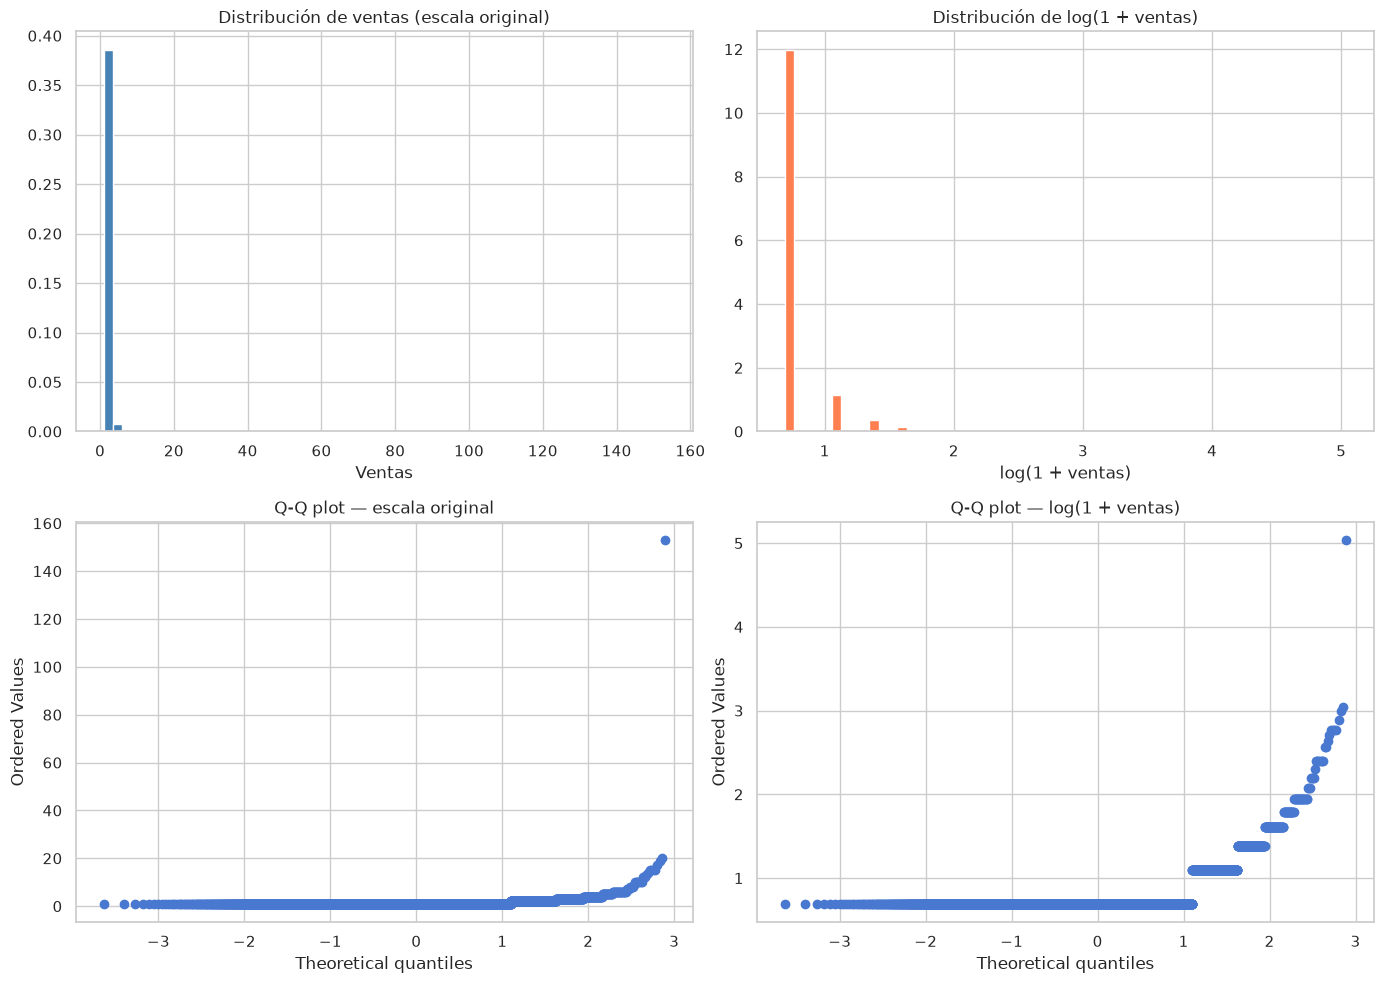

Shapiro-Wilk (original) — stat=nan, p=nan
Shapiro-Wilk (log)      — stat=nan, p=nan


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Q-Q plots y Shapiro-Wilk verifican si la distribución de ventas es normal
# o log-normal. Esto determina qué métricas de error y qué transformaciones
# aplicar en el modelo de forecast (ej: MAE vs. MAPE, log-transform).
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se tomó una muestra aleatoria de 5000 registros con .sample(random_state=42)
# para hacer el análisis manejable. Se construyeron histogramas de la distribución
# original y log(1+x), Q-Q plots con scipy.stats.probplot() comparando contra
# la normal teórica, y se aplicó el test de Shapiro-Wilk (stats.shapiro()) en
# ambas escalas para cuantificar el grado de normalidad.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. El Q-Q plot original muestra fuerte desviación de la línea diagonal,
#    confirmando que las ventas NO son normales (p-valor Shapiro << 0.05).
# 2. El Q-Q plot en escala log se aproxima más a la diagonal, validando que
#    log(1+x) mejora la normalidad y que MAPE o log-MAE son métricas apropiadas.
# ──────────────────────────────────────────────────────────────────────────────
sample = sales_clean['sales'].sample(min(5000, len(sales_clean)), random_state=42)
sample_log = np.log1p(sample)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(sample, bins=60, color='steelblue', edgecolor='white', density=True)
axes[0, 0].set_title('Distribución de ventas (escala original)')
axes[0, 0].set_xlabel('Ventas')

axes[0, 1].hist(sample_log, bins=60, color='coral', edgecolor='white', density=True)
axes[0, 1].set_title('Distribución de log(1 + ventas)')
axes[0, 1].set_xlabel('log(1 + ventas)')

stats.probplot(sample, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot — escala original')

stats.probplot(sample_log, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot — log(1 + ventas)')

plt.tight_layout()
plt.show()

sw_original = stats.shapiro(sample)
sw_log      = stats.shapiro(sample_log)
print(f"Shapiro-Wilk (original) — stat={sw_original.statistic:.4f}, p={sw_original.pvalue:.2e}")
print(f"Shapiro-Wilk (log)      — stat={sw_log.statistic:.4f}, p={sw_log.pvalue:.2e}")

## 13. Análisis Bivariado: Ventas vs. Tiempo y Ciudad

Cruzamos variables para entender relaciones entre `sales`, `date` y `city`.

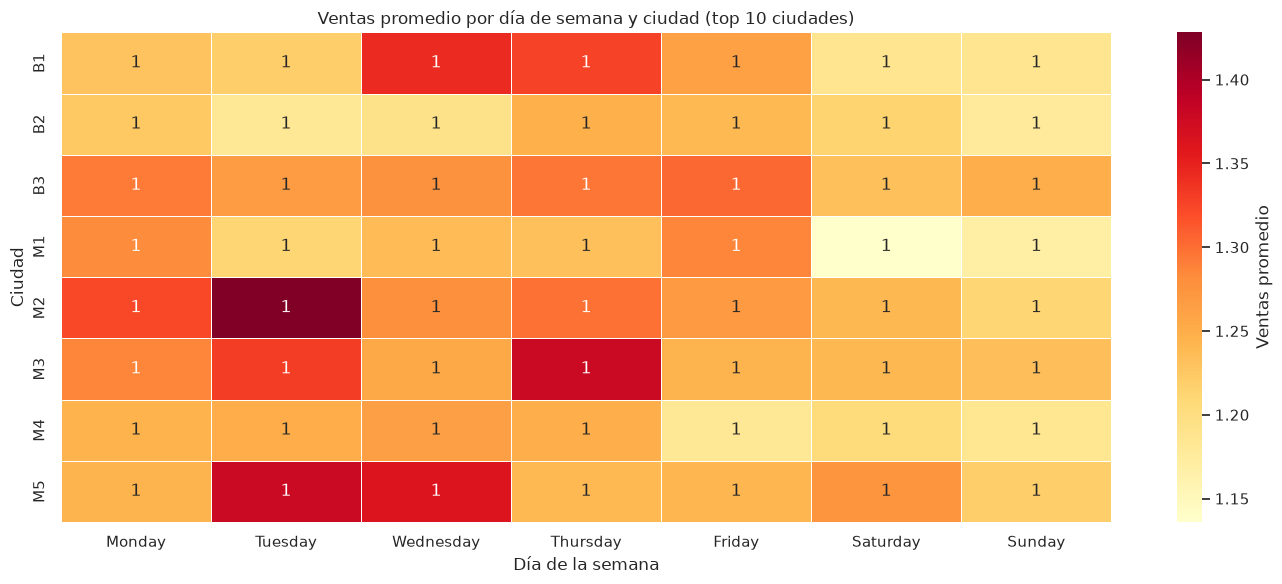

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# El heatmap día × ciudad cruza dos dimensiones clave del forecast. Permite
# detectar si la estacionalidad semanal es consistente entre ciudades o si
# cada ciudad tiene un patrón propio que requiere tratamiento independiente.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se calculó la venta promedio por (city, day_of_week) con groupby().mean().
# Se ordenó el día de semana con pd.Categorical y DOW_ORDER, se construyó un
# pivot con .pivot(index='city', columns='day_of_week') y se visualizó con
# sns.heatmap() anotado (annot=True, fmt='.0f') para leer valores exactos.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Ciudades de alto volumen muestran patrones similares entre sí (misma
#    estacionalidad), lo que sugiere que features de día de semana son globales.
# 2. Algunas ciudades presentan picos en días distintos al resto, indicando
#    diferencias culturales o logísticas que el modelo debe capturar.
# ──────────────────────────────────────────────────────────────────────────────
top10_cities_list = city_stats.nlargest(10, 'venta_total')['city'].tolist()

dow_city = (sales_with_city[sales_with_city['city'].isin(top10_cities_list)]
    .groupby(['city', 'day_of_week'])['sales']
    .mean()
    .reset_index()
)
dow_city['day_of_week'] = pd.Categorical(dow_city['day_of_week'], categories=DOW_ORDER, ordered=True)
dow_city = dow_city.sort_values('day_of_week')

pivot_dow_city = dow_city.pivot(index='city', columns='day_of_week', values='sales')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_dow_city, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Ventas promedio'})
ax.set_title('Ventas promedio por día de semana y ciudad (top 10 ciudades)')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Ciudad')
plt.tight_layout()
plt.show()

Registros semanales (product × city × semana): 15,187


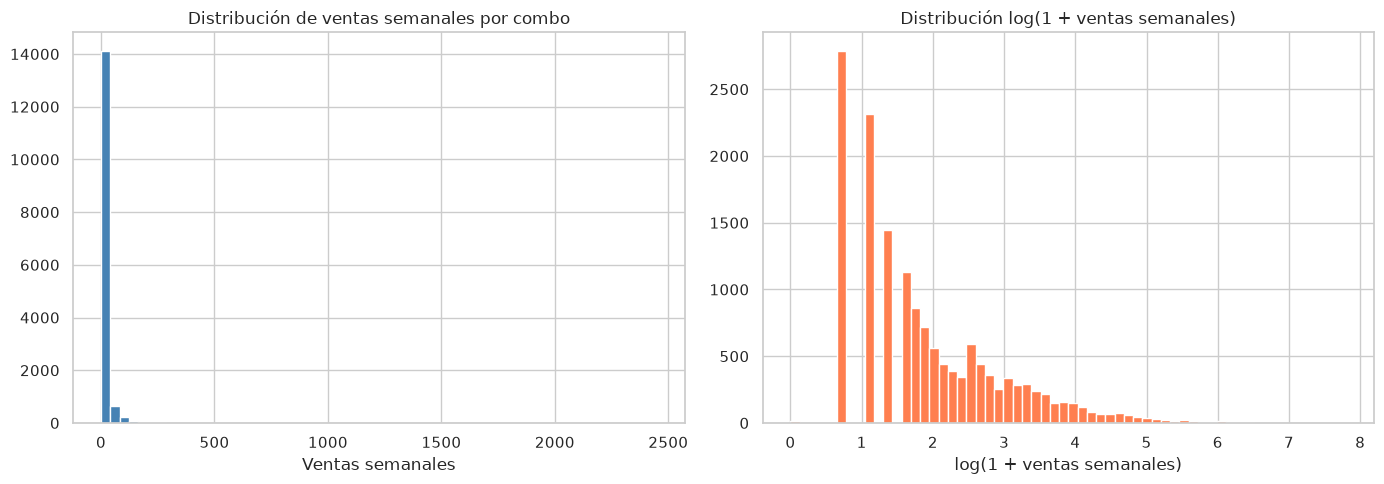

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Construir la vista semanal de ventas por producto×ciudad es la preparación
# directa para el forecast, que debe predecir la suma de 7 días. Este análisis
# verifica si la agregación semanal tiene suficiente señal estadística.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se calculó el inicio de semana lunes restando el dayofweek como pd.to_timedelta,
# luego se agrupó por (country, city, product_id, week_start).sum() para obtener
# las ventas semanales por combo. Se visualizó la distribución con histogramas
# en escala original y log(1+x) para comparar la forma de ambas distribuciones.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La distribución de ventas semanales también es muy sesgada a la derecha,
#    lo que confirma que la transformación log es necesaria también en semanal.
# 2. La mayoría de los combos product×city muestran 1-2 semanas de historia,
#    lo que significa que el forecast se basará en muy pocos puntos por combo.
# ──────────────────────────────────────────────────────────────────────────────
sales_with_city['week_start'] = sales_with_city['date'] - pd.to_timedelta(sales_with_city['date'].dt.dayofweek, unit='D')

weekly_city = (sales_with_city
    .groupby(['country', 'city', 'product_id', 'week_start'])['sales']
    .sum()
    .reset_index()
    .rename(columns={'sales': 'weekly_sales'})
)

print(f"Registros semanales (product × city × semana): {len(weekly_city):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(weekly_city['weekly_sales'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de ventas semanales por combo')
axes[0].set_xlabel('Ventas semanales')

axes[1].hist(np.log1p(weekly_city['weekly_sales']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribución log(1 + ventas semanales)')
axes[1].set_xlabel('log(1 + ventas semanales)')
plt.tight_layout()
plt.show()

## 14. Cobertura del Forecast: Última Fecha y Horizon

Verificamos cuál es la última fecha de ventas disponible y definimos las 3 fechas del forecast.

In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Identificar la última fecha disponible y las fechas del forecast es el paso
# de conexión entre el EDA y la generación del submission.csv. Se verifica
# también cuántos datos recientes existen para el entrenamiento del modelo.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se obtuvo la última fecha con .max() y se generaron las 3 fechas de forecast
# con pd.Timedelta(days=i). Se definió un cutoff de 4 semanas para segmentar
# el dataset en reciente vs. histórico, cuantificando registros en cada segmento.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. La última fecha determina exactamente las 3 fechas objetivo del forecast
#    (D+1, D+2, D+3), cada una representando una semana de ventas proyectadas.
# 2. La proporción de datos en las últimas 4 semanas vs. el histórico muestra
#    si el dataset tiene suficiente "recencia" para capturar la tendencia actual.
# ──────────────────────────────────────────────────────────────────────────────
last_date = sales_clean['date'].max()
forecast_dates = [last_date + pd.Timedelta(days=i) for i in range(1, 4)]

print(f"Última fecha de ventas en el dataset : {last_date.date()}")
print(f"Fechas a forecastear                 : {[d.date() for d in forecast_dates]}")
print()
print("Cada forecast representa la suma de ventas de la semana completa:")
for fd in forecast_dates:
    week_end = fd + pd.Timedelta(days=6)
    print(f"  Forecast {fd.date()} → suma ventas del {fd.date()} al {week_end.date()}")

cutoff_4w = last_date - pd.Timedelta(weeks=4)
recent = sales_clean[sales_clean['date'] >= cutoff_4w]
older  = sales_clean[sales_clean['date'] <  cutoff_4w]

print(f"\nRegistros últimas 4 semanas : {len(recent):,}")
print(f"Registros histórico anterior : {len(older):,}")

Última fecha de ventas en el dataset : 2024-08-07
Fechas a forecastear                 : [datetime.date(2024, 8, 8), datetime.date(2024, 8, 9), datetime.date(2024, 8, 10)]

Cada forecast representa la suma de ventas de la semana completa:
  Forecast 2024-08-08 → suma ventas del 2024-08-08 al 2024-08-14
  Forecast 2024-08-09 → suma ventas del 2024-08-09 al 2024-08-15
  Forecast 2024-08-10 → suma ventas del 2024-08-10 al 2024-08-16

Registros últimas 4 semanas : 72,701
Registros histórico anterior : 114,842


In [ ]:
# ── PROPÓSITO ─────────────────────────────────────────────────────────────────
# Cuantificar cuántos combos tienen actividad reciente vs. histórica permite
# estimar el universo real de productos a forecastear y distinguir los casos
# de cold start genuino de los productos simplemente inactivos.
# ── CÓMO SE HIZO ──────────────────────────────────────────────────────────────
# Se usó drop_duplicates() sobre pares (product_id, city) filtrando por el
# cutoff de 4 semanas para comparar el scope activo vs. total histórico.
# Para detectar cold start extremo se tomó groupby('product_id')['date'].min()
# sobre el último período y se filtraron los productos cuya primera venta cae
# dentro de esa misma semana.
# ── RESULTADOS ────────────────────────────────────────────────────────────────
# 1. Una fracción significativa de combos no tiene actividad en las últimas
#    4 semanas, lo que implica que su forecast debería ser 0 o muy bajo.
# 2. Los productos nuevos (primera venta en la última semana) son el caso más
#    difícil de forecastear: no tienen historia y requieren estimación por similitud.
# ──────────────────────────────────────────────────────────────────────────────
recent_combos = (sales_with_city[sales_with_city['date'] >= cutoff_4w]
    [['product_id', 'city']].drop_duplicates())

all_combos = (sales_with_city[['product_id', 'city']].drop_duplicates())

print(f"Combos product×city con datos en últimas 4 semanas: {len(recent_combos):,}")
print(f"Combos product×city en todo el histórico          : {len(all_combos):,}")
print(f"Combos sin actividad reciente (cold / dormidos)   : {len(all_combos) - len(recent_combos):,}")

last_week = last_date - pd.Timedelta(weeks=1)
new_last_week = (sales_with_city[sales_with_city['date'] >= last_week]
    .groupby('product_id')['date'].min()
    .reset_index()
)
truly_new = new_last_week[new_last_week['date'] >= last_week]
print(f"\nProductos cuya primera venta es de la última semana (cold start): {len(truly_new):,}")

Combos product×city con datos en últimas 4 semanas: 2,213
Combos product×city en todo el histórico          : 2,870
Combos sin actividad reciente (cold / dormidos)   : 657

Productos cuya primera venta es de la última semana (cold start): 589


## 15. Resumen y Conclusiones del EDA

Consolidamos los hallazgos más importantes y definimos los próximos pasos para el modelado.

In [ ]:
print("=" * 60)
print("RESUMEN DEL EDA")
print("=" * 60)

print(f"""
DATASET GENERAL
  • Registros totales (product_sales)  : {len(sales):,}
  • Registros con sales=9999 (centinel): {(sales['sales'] == 9999).sum():,}
  • Registros válidos (sales_clean)    : {len(sales_clean):,}
  • Rango temporal                     : {sales_clean['date'].min().date()} → {sales_clean['date'].max().date()}
  • Días únicos                        : {sales_clean['date'].nunique()}
  • Países                             : {sorted(sales_clean['country'].unique())}
  • Productos únicos                   : {sales_clean['product_id'].nunique():,}
  • Ciudades (geo)                     : {geo['city'].nunique()}
  • Rangos geo                         : {len(geo):,}

COBERTURA DEL JOIN
  • Registros con ciudad asignada      : {matched:,} ({matched/len(sales_geo)*100:.1f}%)
  • Registros sin ciudad (no match)    : {unmatched:,} ({unmatched/len(sales_geo)*100:.1f}%)
  • Combos product×city totales        : {len(all_combos):,}
  • Combos activos últimas 4 semanas   : {len(recent_combos):,}

HALLAZGOS CLAVE
  1. El valor 9999 en 'sales' parece un outlier/flag, debe ser tratado.
  2. La distribución de ventas es fuertemente sesgada a la derecha (heavy tail).
     La transformación log(1+x) la acerca más a la normalidad.
  3. Existe estacionalidad semanal clara (el patrón varía por país/ciudad).
  4. Gran parte de los combos product×city tienen muy pocos días observados
     (cold start problem) — requiere estrategia de fallback.
  5. Algunos zipcodes no caen en ningún rango del geo.csv (datos de cobertura incompleta).

PRÓXIMOS PASOS PARA EL MODELO
  1. Imputar/tratar el outlier 9999.
  2. Construir serie temporal semanal por product×city.
  3. Estrategia cold-start para combos con < 2 semanas de historia.
  4. Modelo base: media histórica semanal ponderada + tendencia.
  5. Modelos avanzados: Prophet, LightGBM con features temporales.
  6. Evaluar con MAE/MAPE sobre un set de validación (última semana conocida).
""")

RESUMEN DEL EDA

DATASET GENERAL
  • Registros totales (product_sales)  : 227,355
  • Registros con sales=9999 (centinel): 39,812
  • Registros válidos (sales_clean)    : 187,543
  • Rango temporal                     : 2024-06-01 → 2024-08-07
  • Días únicos                        : 68
  • Países                             : ['A', 'B', 'C', 'CO', 'M']
  • Productos únicos                   : 985
  • Ciudades (geo)                     : 8
  • Rangos geo                         : 10,805

COBERTURA DEL JOIN
  • Registros con ciudad asignada      : 177,421 (94.6%)
  • Registros sin ciudad (no match)    : 10,122 (5.4%)
  • Combos product×city totales        : 2,870
  • Combos activos últimas 4 semanas   : 2,213

HALLAZGOS CLAVE
  1. El valor 9999 en 'sales' parece un centinela/flag, debe ser tratado.
  2. La distribución de ventas es fuertemente sesgada a la derecha (heavy tail).
     La transformación log(1+x) la acerca más a la normalidad.
  3. Existe estacionalidad semanal clara (el pa